Problem Statement:

# **P4: ANN-Based Customer Response Prediction: Predicting Online Shopper Purchasing Intent**

## Business Goal

The goal of this project is to predict whether an online shopper will complete a purchase during a browsing session. By identifying visitors with a high likelihood of purchasing, businesses can improve conversion rates through targeted marketing, personalized recommendations, and promotional offers. The developed ANN model may support data-driven decision-making aimed at increasing sales and customer engagement.

# 1. Initial Data Understanding

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Dataset from the CSV file
from pathlib import Path

data_path = Path("data/raw/online_shoppers_intention.csv")
if not data_path.exists():
    data_path = Path("../data/raw/online_shoppers_intention.csv")
df = pd.read_csv(data_path)

In [3]:
# Display the first 5 rows of the DataFrame to get an overview of the data
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
# Display the number of rows and columns in the DataFrame
df.shape

(12330, 18)

Interpretation
* The dataset contains 12,330 observations and 18 columns.
* Every column has 12,330 non-null values, indicating complete data.
* There are:
    - 7 integer features
    - 7 float features
    - 2 string features (Month, VisitorType)
    - 2 boolean features (Weekend, Revenue)

In [6]:
# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of the dataset's distribution
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


Key findings:

* Product-related activity dominates user sessions.

Average user visits:

    - ~32 product pages
    - ~2 administrative pages
    - ~0.5 informational pages
* Product browsing duration is substantially higher than other page categories.
* Large gaps between median and maximum values indicate the presence of outliers and right-skewed distributions.
* Features such as ProductRelated_Duration and PageValues contain extreme values that may require further investigation

In [7]:
# Count the occurrences of each unique value in the 'Revenue' column to check class imbalance
df["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


Interpretation

* Revenue Distribution:

    Revenue	Count
    - False	10,422
    - True	1,908

Purchase Rate:

$$
\frac{1908}{12330} \times 100
$$
	​


≈ 15.47%

Meaning:

* Only about 15% of sessions end with a purchase.
* Around 85% do not.
* The dataset is clearly imbalanced.

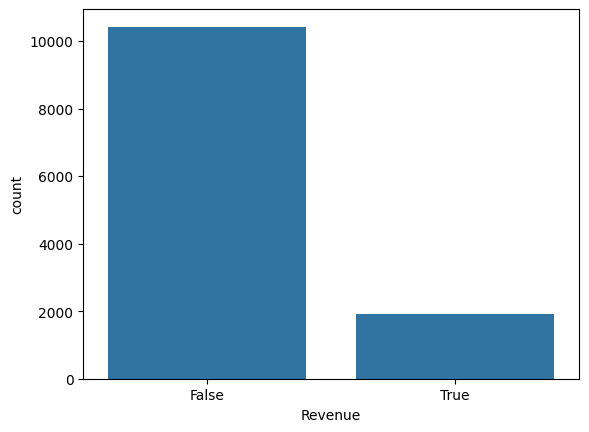

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of the 'Revenue' column using a countplot
sns.countplot(x="Revenue", data=df)
plt.show()

## Revenue Distribution Visualization

The distribution of the target variable confirms a significant class imbalance.

Since purchasing sessions represent a relatively small portion of the data, evaluation metrics such as Precision, Recall, F1-Score, and PR-AUC will be more informative than accuracy alone.

In [9]:
# Display the number of unique values for each column in the DataFrame
df.nunique()

,0
Administrative,27
Administrative_Duration,3335
Informational,17
Informational_Duration,1258
ProductRelated,311
ProductRelated_Duration,9551
BounceRates,1872
ExitRates,4777
PageValues,2704
SpecialDay,6


This tells us:

* Month and VisitorType require categorical encoding.
* Weekend and Revenue are binary variables.
* Browser, Region, TrafficType, and OperatingSystems are encoded categories represented as integers.

# 2. Initial Data Preprocessing

**Data Quality Assessment**


In [10]:
# Check for duplicate rows in the DataFrame and sum them up
df.duplicated().sum()

np.int64(125)

In [11]:
# Remove duplicate rows from the DataFrame
df = df.drop_duplicates()
# Verify that duplicates have been removed by checking the sum of duplicated rows again
df.duplicated().sum()

np.int64(0)

Duplicate Record Analysis

A duplicate check was performed using df.duplicated().sum(). The dataset contained 125 duplicate records. These duplicates were removed using drop_duplicates(), reducing the likelihood of biased analysis and model training. After removal, a second verification confirmed that no duplicate records remained in the dataset.

Result:

Duplicate records detected: 125
Duplicate records removed: 125
Remaining duplicates: 0

Invalid Values Check

In [12]:
# Check for negative values in 'Administrative' column
print(f"Negative values in Administrative: {(df['Administrative'] < 0).sum()}")
# Check for negative values in 'Informational' column
print(f"Negative values in Informational: {(df['Informational'] < 0).sum()}")
# Check for negative values in 'ProductRelated' column
print(f"Negative values in ProductRelated: {(df['ProductRelated'] < 0).sum()}")
# Check for negative values in 'ProductRelated_Duration' column
print(f"Negative values in ProductRelated_Duration: {(df['ProductRelated_Duration'] < 0).sum()}")
# Check for negative values in 'BounceRates' column
print(f"Negative values in BounceRates: {(df['BounceRates'] < 0).sum()}")
# Check for negative values in 'ExitRates' column
print(f"Negative values in ExitRates: {(df['ExitRates'] < 0).sum()}")

Negative values in Administrative: 0
Negative values in Informational: 0
Negative values in ProductRelated: 0
Negative values in ProductRelated_Duration: 0
Negative values in BounceRates: 0
Negative values in ExitRates: 0


Invalid Value Analysis

A validation check was performed on numerical features to identify impossible values, such as negative page counts, negative browsing durations, or invalid rate measurements. No invalid values were detected during the assessment.

Examples checked:

Administrative ≥ 0
Informational ≥ 0
ProductRelated ≥ 0
Duration variables ≥ 0
BounceRates and ExitRates ≥ 0

Result:

Invalid numerical values detected: 0
Data correction required: No

Category Consistency

In [13]:
# Get the unique values present in the 'Month' column
df["Month"].unique()

array(['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep',
       'Dec'], dtype=object)

In [14]:
# Get the unique values present in the 'VisitorType' column
df["VisitorType"].unique()

array(['Returning_Visitor', 'New_Visitor', 'Other'], dtype=object)

Category Consistency Analysis

Categorical variables were examined to identify inconsistent labels, spelling errors, or unexpected category values.

Month Categories Identified:
Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec

VisitorType Categories Identified:
Returning_Visitor
New_Visitor
Other

All categories were found to be valid and consistently formatted.

Result:
Category inconsistencies detected: 0
Category cleaning required: No

Outlier Investigation

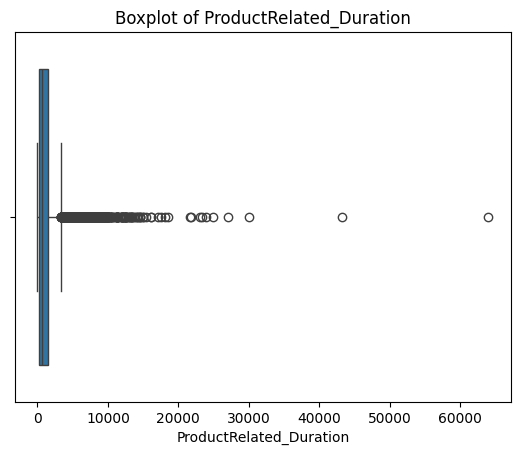

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to visualize outliers in 'ProductRelated_Duration'
sns.boxplot(x=df["ProductRelated_Duration"])
plt.title('Boxplot of ProductRelated_Duration')
plt.show()

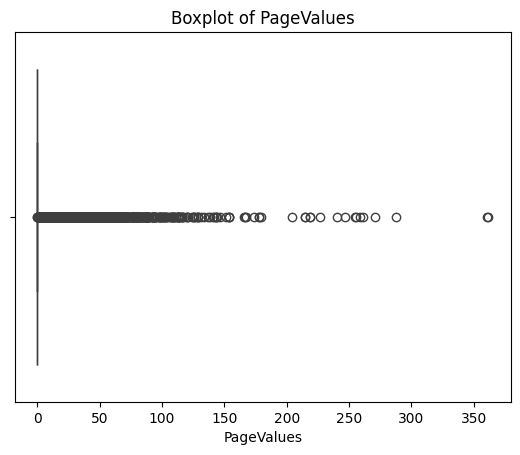

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to visualize outliers in 'PageValues'
sns.boxplot(x=df["PageValues"])
plt.title('Boxplot of PageValues')
plt.show()

In [17]:
# Quantifying the outliers using the IQR method for 'ProductRelated_Duration'
Q1 = df['ProductRelated_Duration'].quantile(0.25)
Q3 = df['ProductRelated_Duration'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df['ProductRelated_Duration'] < lower) |
    (df['ProductRelated_Duration'] > upper)
]

# Print the number of outliers found
print(f"Number of outliers: {len(outliers)}")
# Print the percentage of outliers relative to the total number of records
print(f"Percentage of outliers: {len(outliers) / len(df) * 100:.2f}%")

Number of outliers: 951
Percentage of outliers: 7.79%


Outlier Analysis

Boxplot analysis revealed the presence of numerous statistical outliers in ProductRelated_Duration and PageValues. These observations are primarily concentrated in the upper tail of the distributions, indicating strong positive skewness.

Interpretation
Since these variables represent user browsing behavior and page valuation metrics, the extreme values may correspond to genuine customer activity rather than data entry errors. Therefore, no outlier removal was performed during the cleaning stage.

Future Consideration
Feature scaling and potential logarithmic transformation will be evaluated during preprocessing to mitigate the influence of skewed distributions on model performance.

#3. EDA - Exploratory Data Analysis


#3.1 Univariate Analysis

In [18]:
# List of continuous numerical columns selected for univariate analysis
continuous_cols = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'ProductRelated'
]

In [19]:
# Display summary statistics for the continuous numerical features
# The .T (transpose) is used to make the output more readable
# .style.background_gradient is used for visual emphasis on the statistics
df[continuous_cols].describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Administrative_Duration,12205.000000,81.646331,177.491845,0.000000,0.000000,9.000000,94.700000,3398.750000
Informational_Duration,12205.000000,34.825454,141.424807,0.000000,0.000000,0.000000,0.000000,2549.375000
ProductRelated_Duration,12205.000000,1206.982457,1919.601400,0.000000,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.000000,0.020370,0.045255,0.000000,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.000000,0.041466,0.046163,0.000000,0.014231,0.025000,0.048529,0.200000
PageValues,12205.000000,5.949574,18.653671,0.000000,0.000000,0.000000,0.000000,361.763742
ProductRelated,12205.000000,32.045637,44.593649,0.000000,8.000000,18.000000,38.000000,705.000000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(dataframe, column_name, bins=30):
    """
    Plots the distribution of a continuous numerical column.
    """
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=dataframe,
        x=column_name,
        kde=True,
        bins=bins
    )

    plt.title(f'Distribution of {column_name}', fontsize=14)
    plt.xlabel(column_name)
    plt.ylabel('Frequency')

    plt.show()

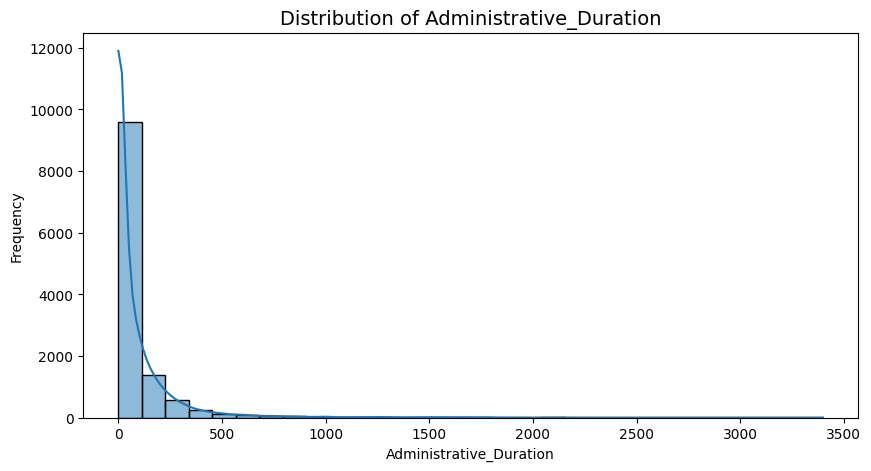

In [21]:
# Plot the distribution of 'Administrative_Duration' using the defined function
plot_distribution(df, 'Administrative_Duration')

## Administrative_Duration

**Key Observations**
- The distribution is **highly right-skewed**, with most users spending very little time on administrative pages.
- A few sessions have extremely high durations, indicating the presence of outliers.
- The long right tail suggests that only a small number of visitors spend significant time on administrative activities.
- This feature may benefit from log transformation or robust scaling before modeling.


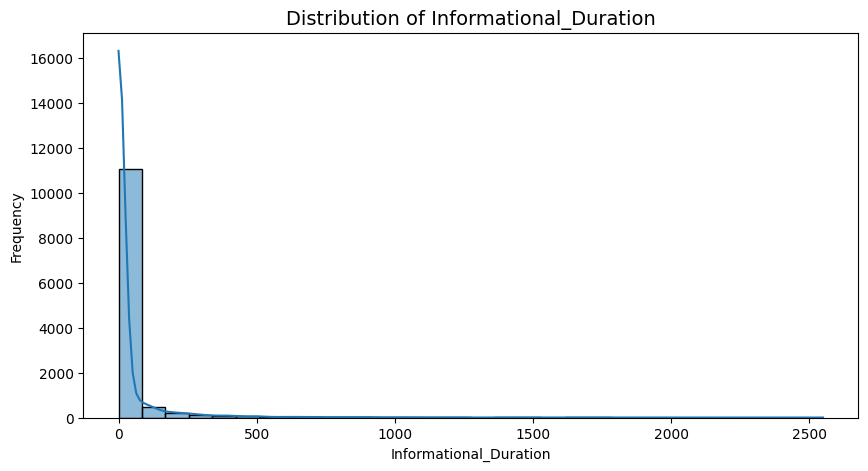

In [22]:
# Plot the distribution of 'Informational_Duration' using the defined function
plot_distribution(df, 'Informational_Duration')

## Informational_Duration

**Key Observations**
- Most observations are concentrated near zero, indicating limited interaction with informational pages.
- The feature exhibits a strong positive skew with a long right tail.
- A small number of users spend substantially more time on informational content than the majority.
- Outliers are present and should be considered during preprocessing.

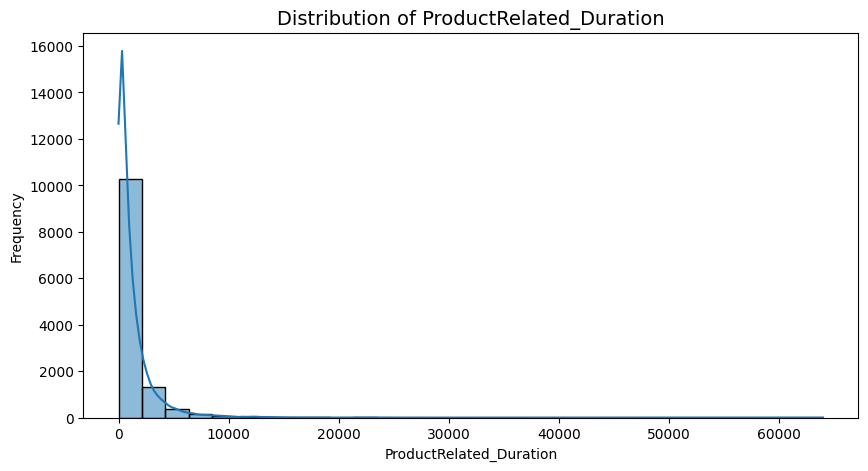

In [23]:
# Plot the distribution of 'ProductRelated_Duration' using the defined function
plot_distribution(df, 'ProductRelated_Duration')

## ProductRelated_Duration

**Key Observations**
- The distribution is extremely right-skewed, with most sessions having relatively low product browsing duration.
- Several extreme outliers represent users who spent a very long time viewing products.
- High-duration sessions may indicate highly engaged customers.
- Log transformation can help reduce skewness for machine learning models.

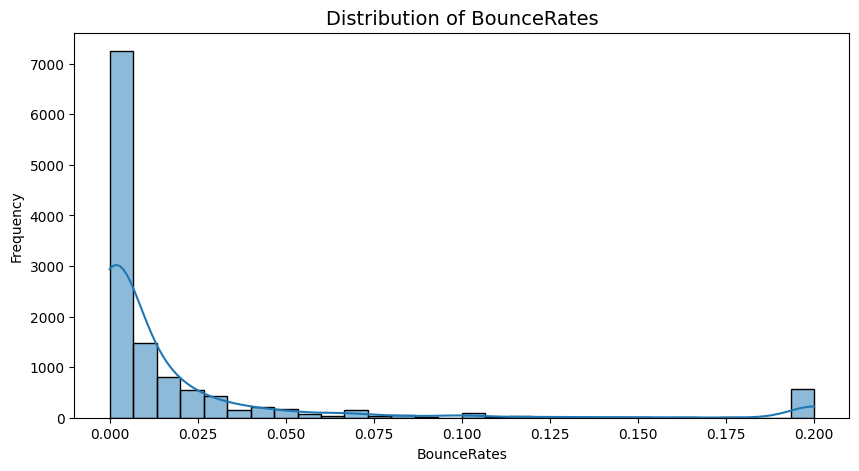

In [24]:
# Plot the distribution of 'BounceRates' using the defined function
plot_distribution(df, 'BounceRates')

## BounceRates

**Key Observations**
- Most bounce rates are very close to zero, suggesting that many sessions continue beyond the landing page.
- The distribution is positively skewed with a noticeable concentration around **0.20**.
- A few higher bounce rate values form the right tail of the distribution.
- Since this feature is bounded, scaling may be sufficient without extensive transformation.

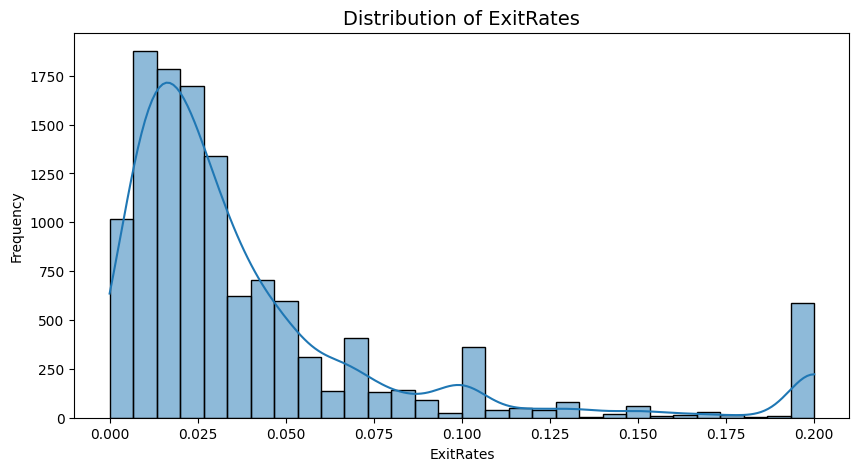

In [25]:
# Plot the distribution of 'ExitRates' using the defined function
plot_distribution(df, 'ExitRates')

## ExitRates

**Key Observations**
- Exit rates are concentrated at lower values but are more spread out than bounce rates.
- The distribution shows moderate positive skewness.
- A visible cluster near **0.20** may indicate commonly occurring maximum exit rates.
- The feature appears informative and may contribute to predicting user behavior.

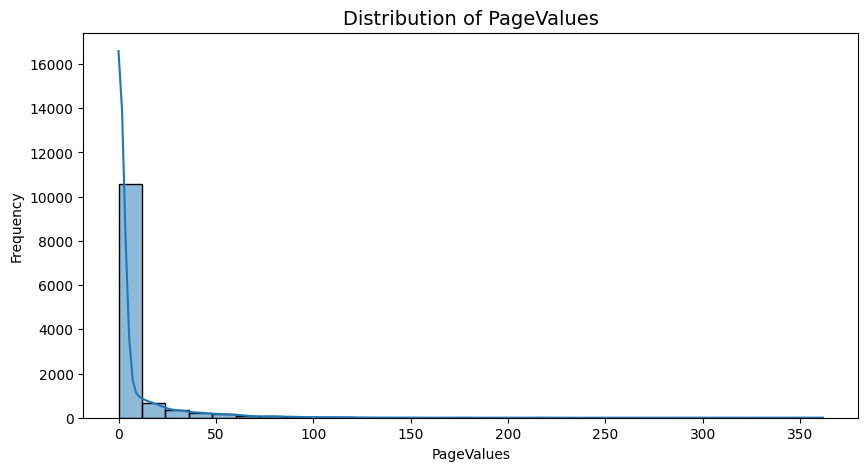

In [26]:
# Plot the distribution of 'PageValues' using the defined function
plot_distribution(df, 'PageValues')

## PageValues

**Key Observations**
- Most page values are zero or very close to zero.
- The distribution is heavily right-skewed with several high-value outliers.
- Only a small proportion of pages contribute significant monetary value.
- The feature contains valuable business information despite its skewed distribution.

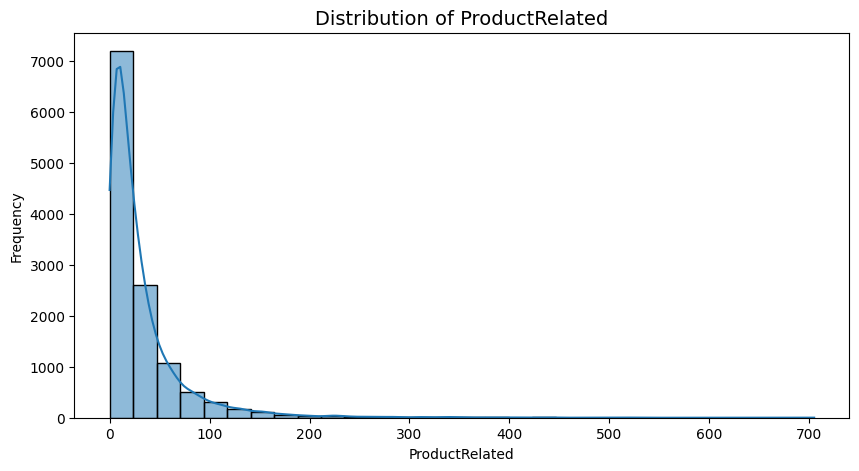

In [27]:
# Plot the distribution of 'ProductRelated' using the defined function
plot_distribution(df, 'ProductRelated')

## ProductRelated

**Key Observations**
- Most sessions involve viewing only a small number of product-related pages.
- The feature exhibits a strong right-skew with a long tail.
- A few users browse a very large number of products, creating outliers.
- High product page counts may indicate stronger purchase intent or higher engagement.

In [28]:
# Outlier analysis using boxplots
def plot_boxplot(dataframe, column_name):
    """
    Plots a boxplot for a continuous numerical column to analyze outliers.
    """
    plt.figure(figsize=(10, 2))

    sns.boxplot(
        x=dataframe[column_name]
    )

    plt.title(f'Boxplot of {column_name}', fontsize=14)
    plt.show()

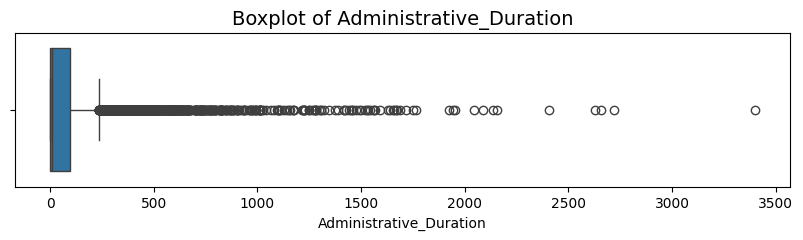

In [29]:
# Plot a boxplot for 'Administrative_Duration' to visualize outliers
plot_boxplot(df, 'Administrative_Duration')

## Administrative_Duration

**Key Observations**
- The boxplot confirms the presence of numerous extreme outliers.
- Most observations are concentrated within a small range, resulting in a compressed box.
- The feature exhibits strong positive skewness with a long right tail.
- Outliers may represent genuine high-engagement sessions rather than data errors.

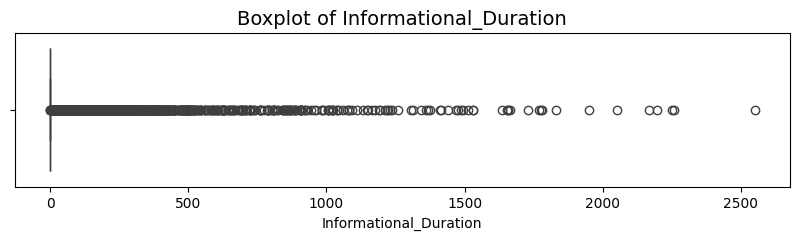

In [30]:
# Plot a boxplot for 'Informational_Duration' to visualize outliers
plot_boxplot(df, 'Informational_Duration')

## Informational_Duration

**Key Observations**
- The majority of values are clustered near zero.
- A large number of high-value outliers are visible beyond the upper whisker.
- The distribution is highly right-skewed.
- Outlier treatment should be considered based on the modeling objective.

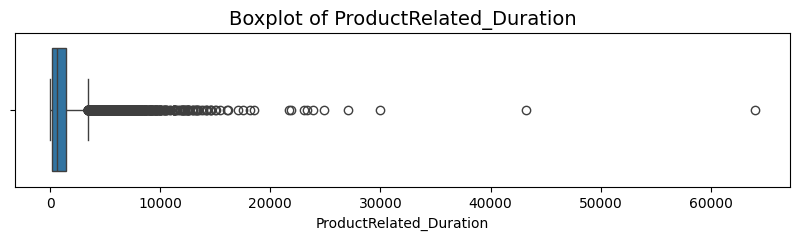

In [31]:
# Plot a boxplot for 'ProductRelated_Duration' to visualize outliers
plot_boxplot(df, 'ProductRelated_Duration')


## ProductRelated_Duration

**Key Observations**
- The feature contains a substantial number of extreme outliers.
- Most sessions have relatively low browsing durations, while a few extend to exceptionally high values.
- The distribution is heavily right-skewed.
- These extreme values may correspond to highly engaged customers.

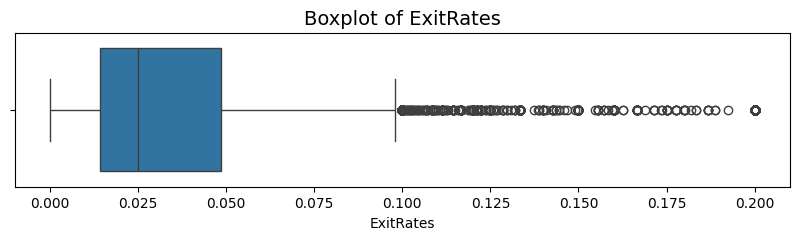

In [32]:
# Plot a boxplot for 'ExitRates' to visualize outliers
plot_boxplot(df, 'ExitRates')

## ExitRates

**Key Observations**
- Several observations lie above the upper whisker, indicating moderate outliers.
- The central 50% of values fall within a relatively narrow range.
- The distribution shows moderate positive skewness.
- High exit rates may warrant further investigation.

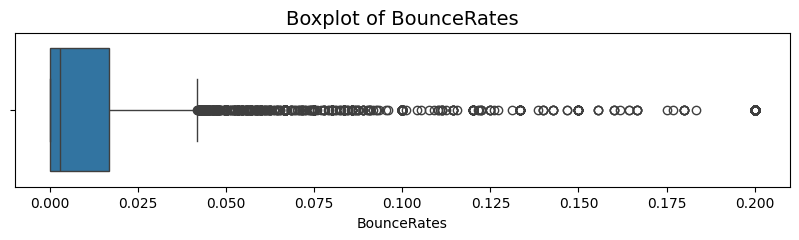

In [33]:
# Plot a boxplot for 'BounceRates' to visualize outliers
plot_boxplot(df, 'BounceRates')

## BounceRates

**Key Observations**
- Most observations are concentrated near zero.
- Numerous outliers exist above the upper whisker.
- The feature is positively skewed with a long upper tail.
- Higher bounce rates may indicate low user engagement.

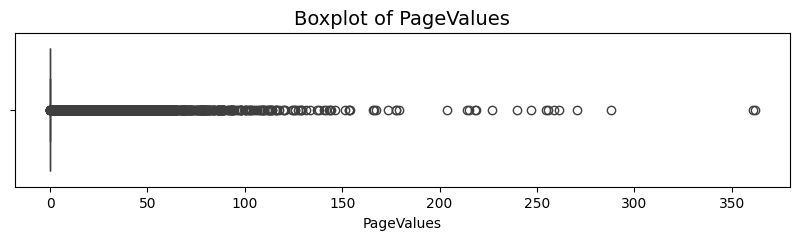

In [34]:
# Plot a boxplot for 'PageValues' to visualize outliers
plot_boxplot(df, 'PageValues')


## PageValues

**Key Observations**
- The majority of page values are close to zero.
- Many high-value outliers are present beyond the upper whisker.
- The distribution is strongly right-skewed.
- Large page values likely represent high-value customer interactions.

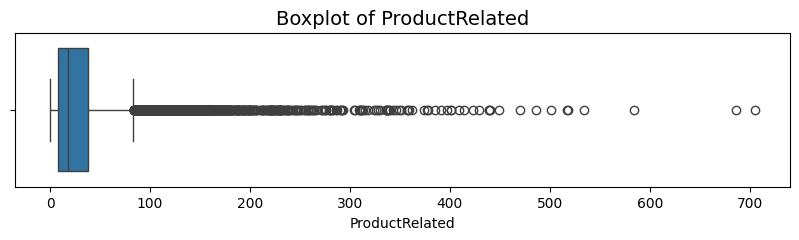

In [35]:
# Plot a boxplot for 'ProductRelated' to visualize outliers
plot_boxplot(df,'ProductRelated')

## ProductRelated

**Key Observations**
- Most users view a relatively small number of product pages.
- A considerable number of high-value outliers are observed.
- The feature exhibits a long right tail and positive skewness.
- Sessions with many product views may indicate stronger purchase intent.

## Overall Summary of Univariate Analysis

The univariate analysis reveals that the majority of numerical features in the dataset exhibit **strong positive (right) skewness**, where most observations are concentrated at lower values with a long tail extending toward higher values. This indicates that while most users spend relatively little time interacting with the website, a small subset of users demonstrate significantly higher engagement.

The boxplots further confirm the presence of **numerous outliers** across duration-based, count-based, and value-based features. These outliers are likely to represent genuine user behavior—such as highly engaged visitors—rather than data quality issues. Therefore, they should be carefully evaluated before considering removal.

### Key Findings

- **Highly Right-Skewed Features**
  - Administrative_Duration
  - Informational_Duration
  - ProductRelated_Duration
  - ProductRelated
  - PageValues
  - BounceRates
  - ExitRates

- **Outlier Analysis**
  - All analyzed numerical features contain outliers, with **ProductRelated_Duration** showing the most extreme values.
  - Duration and engagement-related variables contain particularly long upper tails, indicating a small number of highly active sessions.

- **Business Insights**
  - Most visitors interact briefly with administrative, informational, and product-related pages.
  - Only a small proportion of users spend substantial time browsing products or generate high page values, suggesting that highly engaged sessions are relatively rare but potentially more valuable.
  - Low BounceRates and ExitRates dominate the dataset, indicating that many sessions continue beyond the landing page, although a subset of users exits quickly.

- **Implications for Data Preprocessing**
  - Most numerical features are **non-normally distributed**, making transformations such as `log1p()` suitable for reducing skewness.
  - Since the dataset contains many genuine extreme observations, **RobustScaler** is likely to be more appropriate than StandardScaler.
  - Outliers should not be removed blindly, as they may carry meaningful business information related to high customer engagement or purchase intent.

Overall, the dataset exhibits characteristics commonly observed in web analytics data, where a large proportion of users display minimal interaction while a relatively small group accounts for the majority of engagement. These insights provide a strong foundation for feature engineering, preprocessing, and subsequent predictive modeling.

In [36]:
# Distribution analysis of discrete numerical features

def plot_discrete_distribution(dataframe, column_name):
    """
    Plots the distribution of a discrete numerical column.
    """
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=dataframe,
        x=column_name,
        discrete=True
    )

    plt.title(f'Distribution of {column_name}', fontsize=14)
    plt.xlabel(column_name)
    plt.ylabel('Frequency')

    plt.show()

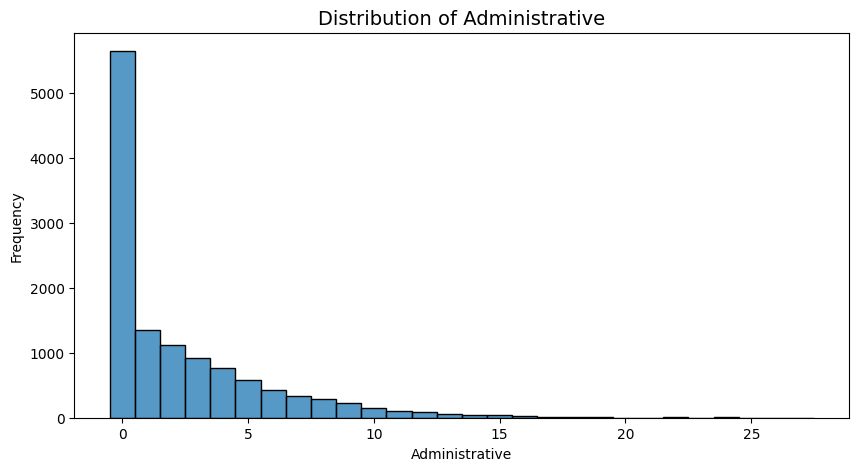

In [37]:
# Plot the distribution of 'Administrative' (discrete numerical) using the defined function
plot_discrete_distribution(df, 'Administrative')

## Administrative

**Key Observations**
- The distribution is highly right-skewed, with most sessions having very few administrative page visits.
- A large proportion of users did not visit any administrative pages.
- The frequency decreases steadily as the number of administrative pages increases.
- Only a small number of users visited a large number of administrative pages.

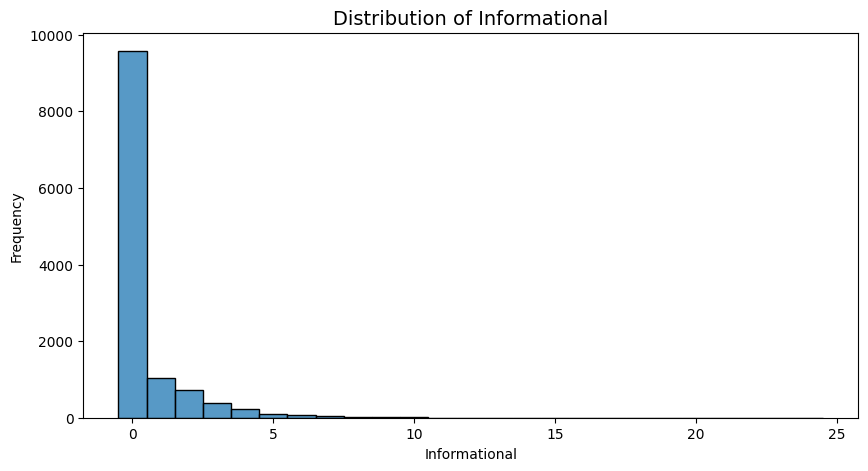

In [38]:
# Plot the distribution of 'Informational' (discrete numerical) using the defined function
plot_discrete_distribution(df, 'Informational')

## Informational

**Key Observations**
- Most users viewed no informational pages, resulting in a large concentration at zero.
- The distribution is strongly right-skewed with a long right tail.
- The number of sessions decreases rapidly as informational page visits increase.
- Only a few users explored a high number of informational pages.

## Overall Summary of Discrete Numerical Features

The discrete numerical features **Administrative** and **Informational** exhibit similar distribution patterns. Both are **highly right-skewed**, with the majority of observations concentrated at zero or very low values, indicating that most visitors interact with only a few or none of these pages during a session.

### Key Findings

- Both features are **positively skewed**, with frequencies decreasing as the number of page visits increases.
- A significant proportion of users did **not visit any administrative or informational pages**.
- Higher page visit counts are relatively rare, suggesting that only a small subset of users actively explores these sections of the website.
- The observed distributions indicate that these features capture occasional user behavior rather than routine browsing activity.

### Business Insight

The analysis suggests that most website sessions involve limited interaction with administrative and informational content. Users who visit multiple pages in these categories may represent more engaged visitors, making these features potentially useful for identifying customer engagement and purchase intent in predictive models.

In [39]:
# List of categorical columns selected for univariate analysis
categorical_cols = [
    'Month',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'VisitorType',
    'Weekend'
]

In [40]:
def plot_categorical_distribution(dataframe, column_name):
    """
    Plots a countplot for a categorical column to analyze the frequency of categories.
    """
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=dataframe,
        x=column_name,
        palette='viridis' # Optional: Adds a nice color palette
    )

    plt.title(f'Distribution of {column_name}', fontsize=14)
    plt.xlabel(column_name)
    plt.ylabel('Count')

    # Rotating x-labels in case category names are long and overlap
    plt.xticks(rotation=45)

    plt.show()

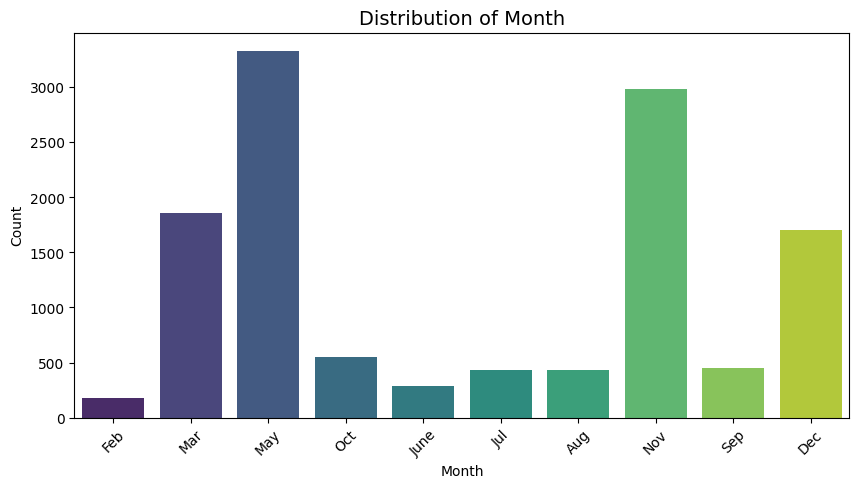

In [41]:
# Plot the distribution of 'Month' (categorical) using the defined function
plot_categorical_distribution(df, 'Month')

## Month

**Key Observations**
- Website traffic is unevenly distributed across months.
- **May** and **November** record the highest number of sessions.
- February has the fewest observations in the dataset.
- The variation suggests possible seasonal effects on user activity.

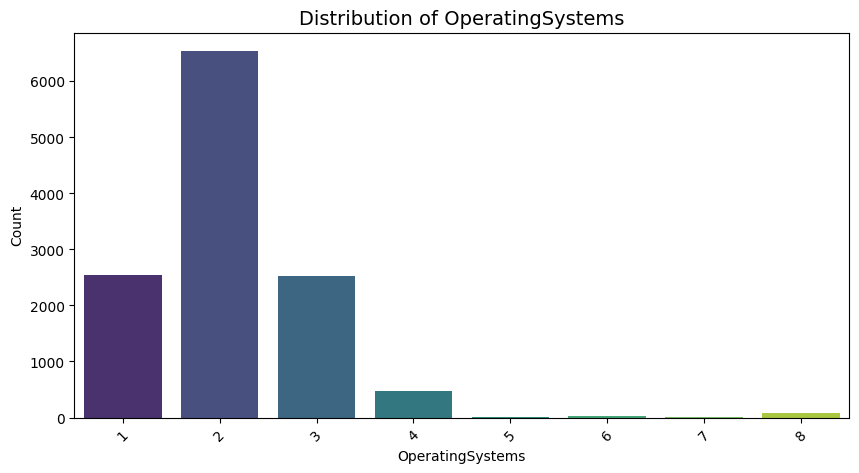

In [42]:
# Plot the distribution of 'OperatingSystems' (categorical) using the defined function
plot_categorical_distribution(df, 'OperatingSystems')

## OperatingSystems

**Key Observations**
- Operating System **2** is the most frequently used.
- Operating Systems **1** and **3** also account for a substantial share of sessions.
- The remaining operating systems have very few observations.
- The distribution is highly imbalanced across categories.

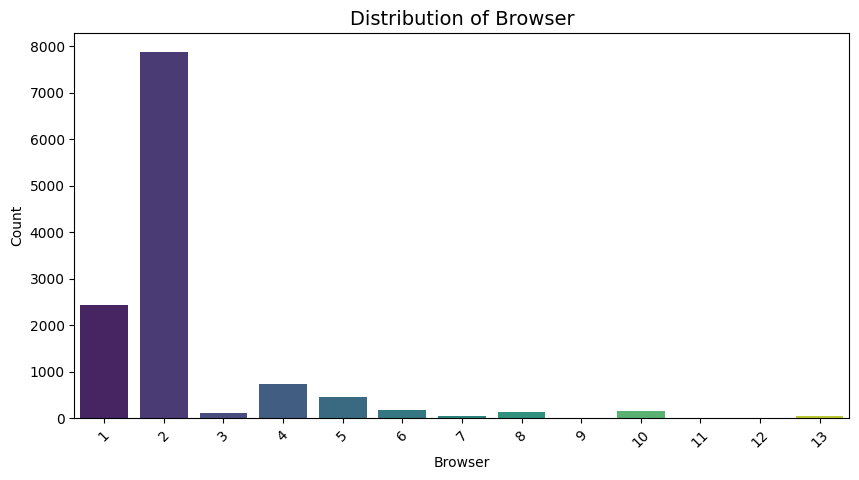

In [43]:
# Plot the distribution of 'Browser' (categorical) using the defined function
plot_categorical_distribution(df, 'Browser')

## Browser

**Key Observations**
- Browser **2** dominates the dataset by a large margin.
- Browser **1** is the second most common.
- All remaining browsers contribute relatively few sessions.
- The browser distribution is heavily skewed toward a few categories.

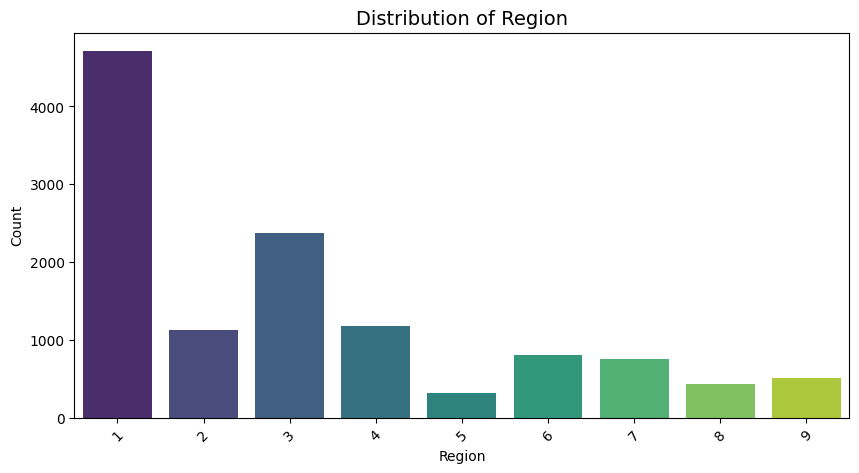

In [44]:
# Plot the distribution of 'Region' (categorical) using the defined function
plot_categorical_distribution(df, 'Region')


## Region

**Key Observations**
- Region **1** contains the largest number of sessions.
- Regions **3** and **4** also contribute a notable share of traffic.
- Several regions have comparatively low representation.
- User activity is unevenly distributed across geographic regions.


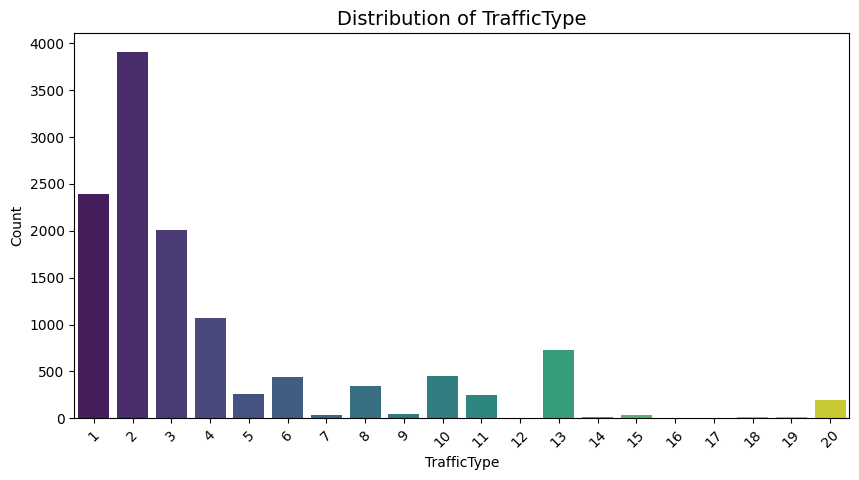

In [45]:
# Plot the distribution of 'TrafficType' (categorical) using the defined function
plot_categorical_distribution(df, 'TrafficType')

## TrafficType

**Key Observations**
- Traffic Types **2**, **1**, and **3** account for the majority of website visits.
- Several traffic sources contribute only a small number of sessions.
- The distribution is highly imbalanced across traffic channels.
- Less common traffic types may represent niche acquisition sources.

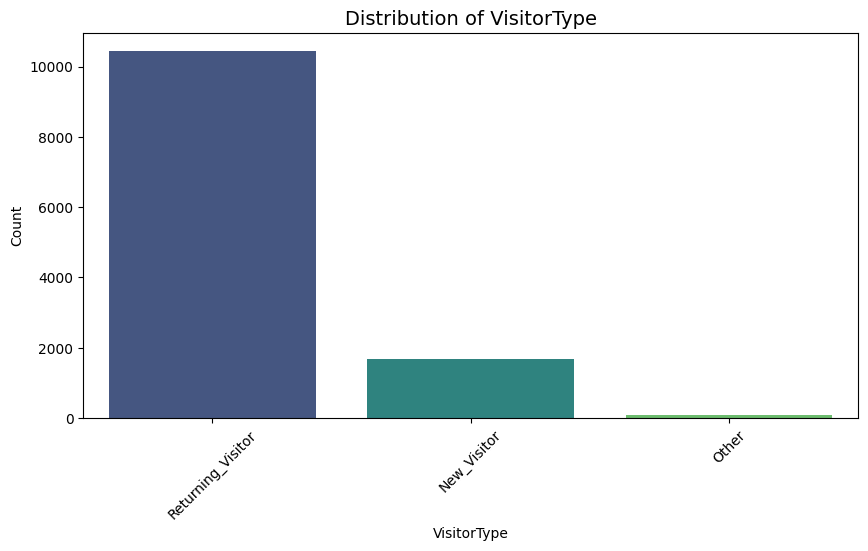

In [46]:
# Plot the distribution of 'VisitorType' (categorical) using the defined function
plot_categorical_distribution(df, 'VisitorType')

## VisitorType

**Key Observations**
- **Returning Visitors** make up the overwhelming majority of sessions.
- **New Visitors** account for a much smaller portion of website traffic.
- The **Other** category contains very few observations.
- The dataset primarily represents returning users.


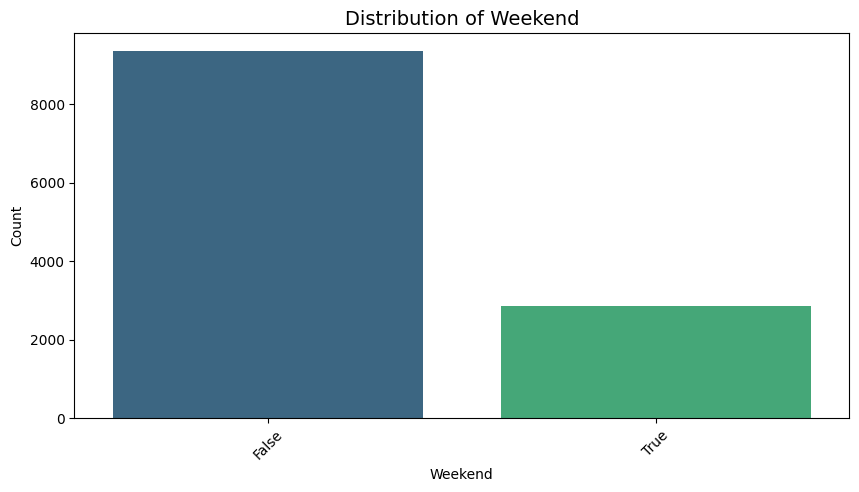

In [47]:
# Plot the distribution of 'Weekend' (categorical) using the defined function
plot_categorical_distribution(df, 'Weekend')

## Weekend

**Key Observations**
- Most sessions occurred on **weekdays**.
- Weekend sessions represent a much smaller share of the data.
- The feature exhibits a clear class imbalance.
- User activity appears to be concentrated during weekdays.

## Overall Summary of Categorical Feature Analysis

The categorical feature analysis shows that several variables exhibit **highly imbalanced distributions**, where a few categories dominate the dataset while others contain relatively few observations. This indicates that user behavior, device usage, traffic sources, and visit timing are concentrated around specific categories rather than being uniformly distributed.

### Key Findings

- **Seasonality**
  - Website traffic varies noticeably across months, with **May** and **November** recording the highest number of sessions.
  - This suggests the presence of seasonal trends that may influence user behavior and purchasing activity.

- **Technology Usage**
  - A small number of operating systems and browsers account for the majority of website visits.
  - This indicates that most users access the website using a limited set of devices and browsers.

- **Geographical Distribution**
  - User sessions are unevenly distributed across regions, with **Region 1** contributing the largest share of traffic.
  - Several regions have relatively low representation in the dataset.

- **Traffic Sources**
  - A few traffic types generate most of the website visits, while many traffic sources contribute only a small fraction of sessions.
  - This suggests that customer acquisition relies heavily on a limited number of channels.

- **Visitor Behavior**
  - **Returning Visitors** dominate the dataset, indicating that repeat users make up the majority of website traffic.
  - New visitors represent a smaller proportion, suggesting strong user retention.

- **Visit Timing**
  - Most website sessions occur on **weekdays**, with comparatively fewer visits during weekends.
  - This indicates that user activity is concentrated during the workweek.

### Business Insight

The categorical analysis suggests that website traffic is driven by a **small number of dominant categories**, including specific months, browsers, operating systems, traffic sources, and returning visitors. These patterns provide valuable insights for customer segmentation, marketing strategy, and predictive modeling, as the identified categories are likely to have a significant influence on user engagement and purchasing behavior.

#3.2 Biavariate Analysis

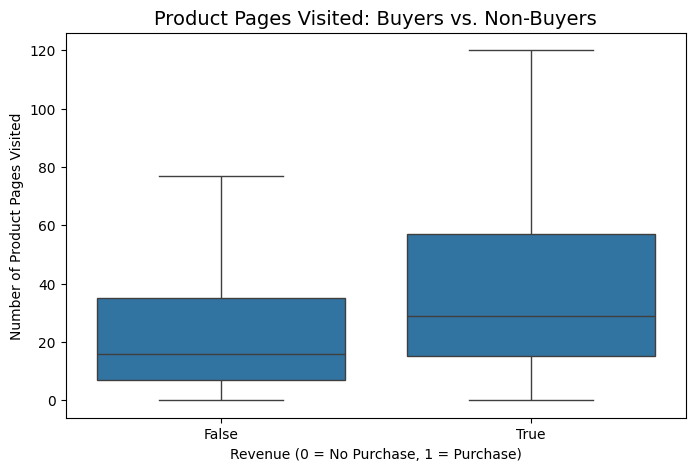

In [48]:
# Do buyers visit more product pages?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Revenue', y='ProductRelated', showfliers=False)
plt.title('Product Pages Visited: Buyers vs. Non-Buyers', fontsize=14)
plt.xlabel('Revenue (0 = No Purchase, 1 = Purchase)')
plt.ylabel('Number of Product Pages Visited')
plt.show()

## Product Pages Visited: Buyers vs. Non-Buyers

**Key Observations**
- Buyers generally visit more product pages than non-buyers.
- The median number of product pages viewed is noticeably higher for buyers.
- Buyers also exhibit greater variability in browsing behavior.
- Increased product exploration appears to be associated with a higher likelihood of purchase.

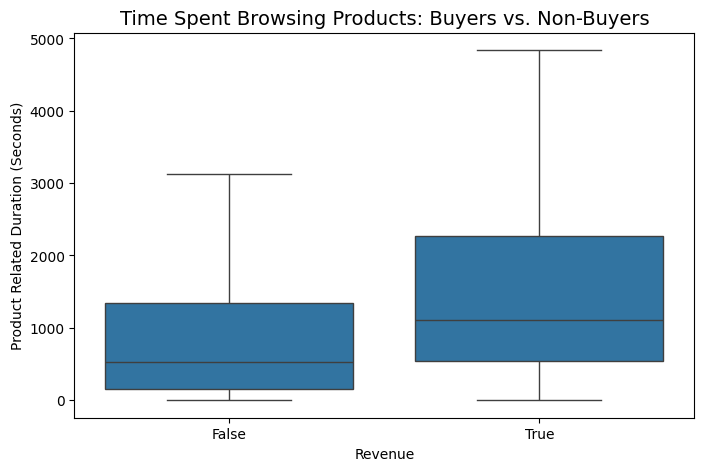

In [49]:
# Do buyers spend more time browsing?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Revenue', y='ProductRelated_Duration',showfliers=False)
plt.title('Time Spent Browsing Products: Buyers vs. Non-Buyers', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Product Related Duration (Seconds)')
plt.show()

## ProductRelated_Duration: Buyers vs. Non-Buyers

**Key Observations**
- Buyers spend substantially more time browsing product-related pages.
- The median browsing duration is considerably higher for buyers.
- Buyers show a wider spread of browsing times, indicating varying levels of engagement.
- Longer product browsing duration is positively associated with conversions.

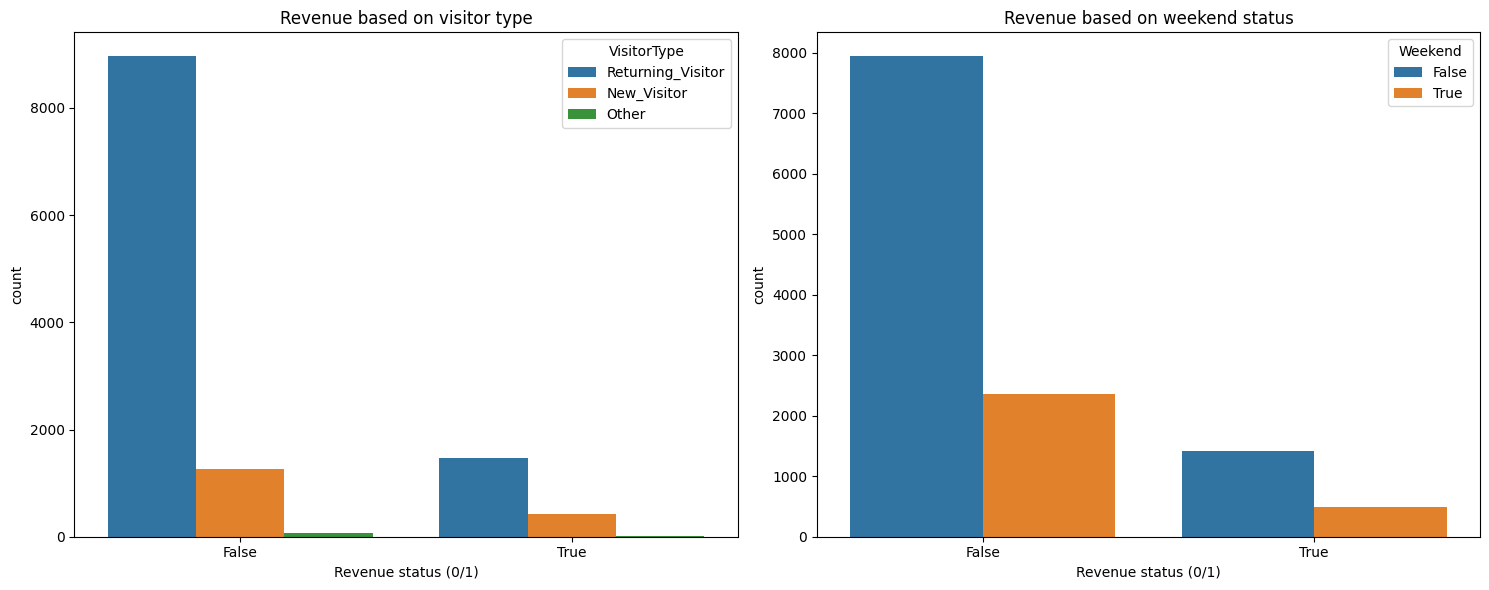

In [50]:
# Revenue by Visistortype and Weekend Status
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=df, x='Revenue', hue='VisitorType', ax=axes[0])
axes[0].set_title("Revenue based on visitor type")
axes[0].set_xlabel("Revenue status (0/1)")

sns.countplot(data=df, x='Revenue', hue='Weekend', ax=axes[1])
axes[1].set_title("Revenue based on weekend status")
axes[1].set_xlabel("Revenue status (0/1)")

plt.tight_layout()
plt.show()

## VisitorType vs. Revenue

**Key Observations**
- Returning visitors account for the majority of purchases.
- Although new visitors generate some purchases, their conversion count is much lower.
- The "Other" visitor category contributes very few sessions and purchases.
- Returning visitors appear to have a higher purchase propensity.
## Revenue by Weekend Status

**Key Observations**
- Most purchases occur on weekdays due to higher overall traffic.
- Weekend sessions are fewer but still contribute to conversions.
- Purchases occur on both weekdays and weekends.
- Weekend alone does not appear to be a strong differentiating factor for revenue.

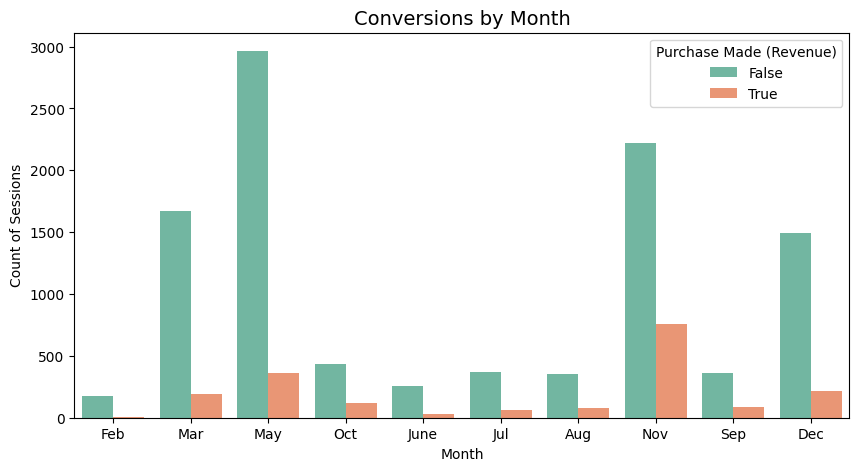

In [51]:
# Which month has the highest conversions?
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Month', hue='Revenue', palette='Set2')
plt.title('Conversions by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Count of Sessions')
plt.legend(title='Purchase Made (Revenue)')
plt.show()


## Conversions by Month
**Key Observations**
- November records the highest number of purchases among all months.
- May has the highest overall traffic but comparatively fewer conversions than November.
- Purchase activity varies noticeably across months, suggesting seasonal trends.
- Conversion performance is not solely determined by total website traffic.

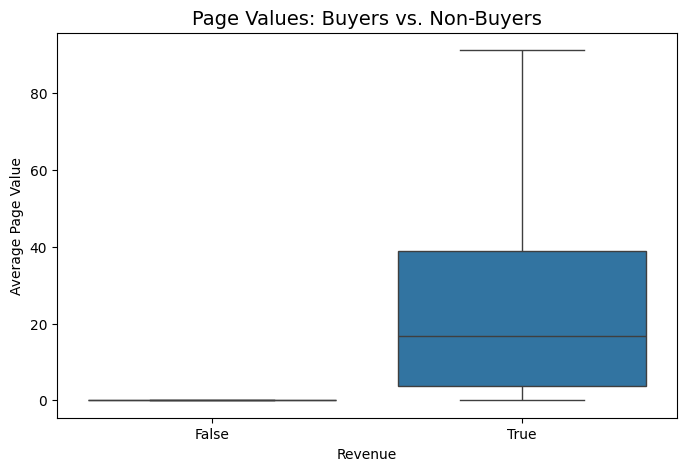

In [52]:
# Does PageValues differ between buyers and non-buyers?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Revenue', y='PageValues',showfliers=False)
plt.title('Page Values: Buyers vs. Non-Buyers', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Average Page Value')
plt.show()


## PageValues: Buyers vs. Non-Buyers

**Key Observations**
- Non-buyers have PageValues close to zero across nearly all sessions.
- Buyers exhibit significantly higher PageValues with greater variability.
- A clear separation exists between buyers and non-buyers for this feature.
- PageValues appear to be a strong indicator of purchase behavior.

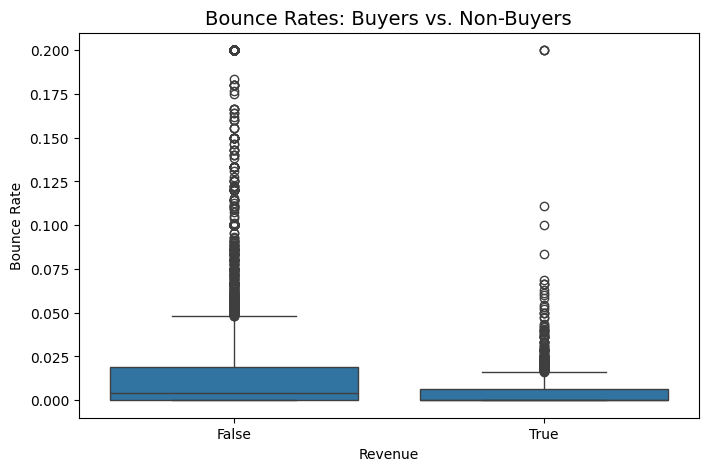

In [53]:
# Do bounce rates affect purchases?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Revenue', y='BounceRates')
plt.title('Bounce Rates: Buyers vs. Non-Buyers', fontsize=14)
plt.xlabel('Revenue')
plt.ylabel('Bounce Rate')
plt.show()

## BounceRates: Buyers vs. Non-Buyers

**Key Observations**
- Buyers generally have lower bounce rates than non-buyers.
- Non-buyers display a wider spread and more high bounce-rate observations.
- Lower bounce rates are associated with higher purchase likelihood.
- BounceRate may serve as a useful engagement indicator for predicting conversions.

## Overall Summary of Bivariate Analysis

The bivariate analysis highlights several factors that distinguish buyers from non-buyers. Features related to **user engagement**, such as the number of product pages visited, time spent browsing products, PageValues, and BounceRates, show clear differences between the two groups. These findings suggest that user engagement plays a significant role in purchase behavior.

### Key Findings

- **Product Engagement**
  - Buyers visit more product-related pages and spend significantly more time browsing products than non-buyers.
  - Higher browsing activity is strongly associated with an increased likelihood of making a purchase.

- **Page Value**
  - Buyers consistently have much higher PageValues, while non-buyers have values close to zero.
  - This feature provides one of the clearest distinctions between purchasing and non-purchasing sessions.

- **Visitor Type**
  - Returning visitors account for the majority of purchases.
  - Although new visitors contribute to sales, their purchase volume is considerably lower than that of returning visitors.

- **Seasonality**
  - Purchase activity varies across months, with **November** showing the highest number of conversions.
  - Months with the highest traffic do not necessarily achieve the highest conversion rates, indicating seasonal differences in user purchase intent.

- **User Engagement**
  - Buyers generally exhibit lower bounce rates than non-buyers.
  - Lower bounce rates indicate that engaged users are more likely to continue exploring the website and complete a purchase.

### Business Insights

The analysis indicates that **customer engagement is the strongest driver of online purchases**. Users who browse more products, spend longer exploring product pages, generate higher PageValues, and exhibit lower bounce rates are substantially more likely to convert. Additionally, returning visitors contribute the majority of purchases, emphasizing the importance of customer retention strategies. Seasonal patterns—particularly the strong performance observed in November—also suggest that marketing campaigns and inventory planning should align with periods of higher purchase intent.

Overall, the bivariate analysis identifies **ProductRelated**, **ProductRelated_Duration**, **PageValues**, **BounceRates**, **VisitorType**, and **Month** as influential features for understanding and predicting customer purchase behavior. These variables are strong candidates for feature selection in the predictive modeling stage.

#3.3 Correlation Analysis

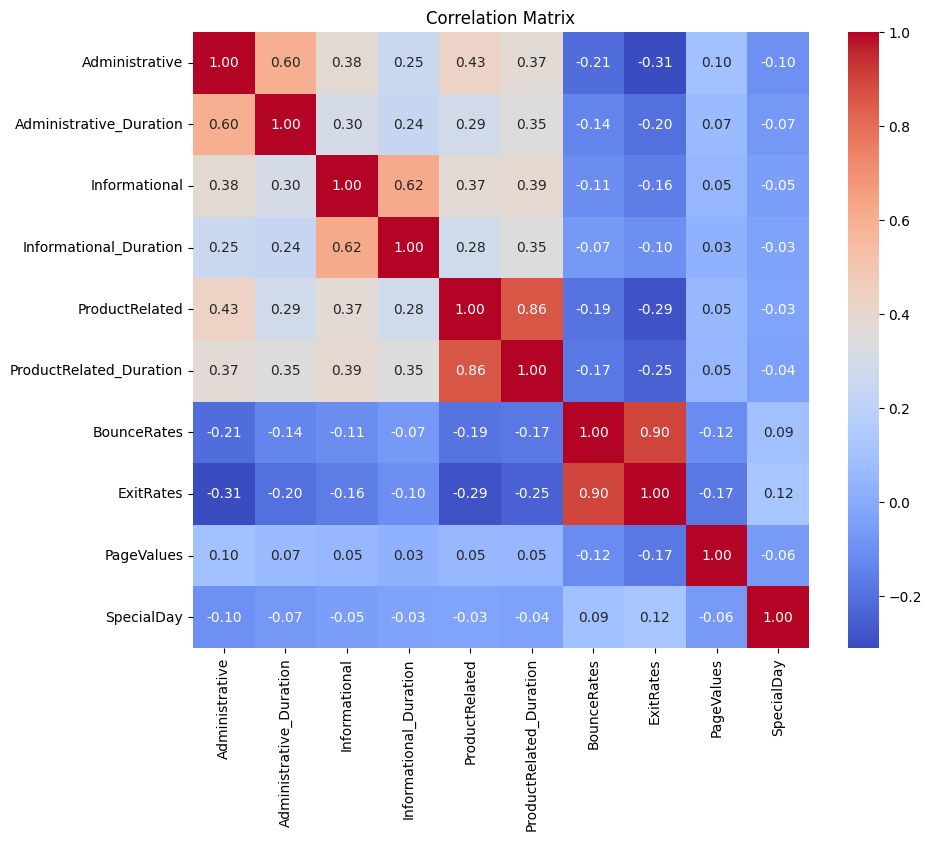

In [54]:
# Calculate the correlation matrix for the first 10 numerical columns.
plt.figure(figsize=(10, 8))
correlation = df.iloc[:, 0:10].corr()
# Create a heatmap to visualize the correlation matrix.
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis

### Key Observations

- **Strong Positive Correlations**
  - **BounceRates** and **ExitRates** exhibit a **very strong positive correlation (0.90)**, indicating that both features capture similar user behavior.
  - **ProductRelated** and **ProductRelated_Duration** also show a strong positive correlation (0.86), suggesting that users who visit more product pages generally spend more time browsing them.

- **Moderate Positive Correlations**
  - **Informational** and **Informational_Duration** have a moderate correlation (0.62), indicating that more informational page visits are associated with longer browsing durations.
  - **Administrative** and **Administrative_Duration** are moderately correlated (0.60), reflecting similar browsing patterns for administrative pages.

- **Negative Correlations**
  - **ExitRates** shows moderate negative correlations with engagement-related features such as **Administrative (-0.31)** and **ProductRelated (-0.29)**.
  - **BounceRates** also has weak to moderate negative correlations with page interaction features, suggesting that increased user engagement is associated with lower bounce and exit rates.

- **Weak Correlations**
  - **PageValues** exhibits generally weak linear correlations with other numerical features, indicating that it captures unique information.
  - **SpecialDay** has negligible correlations with nearly all variables, suggesting minimal linear association with browsing behavior.

### Business Insights

The correlation analysis indicates that users who browse more pages tend to spend more time on those pages, reflecting consistent engagement patterns across the website. Additionally, the strong relationship between **BounceRates** and **ExitRates** suggests potential redundancy, making them candidates for feature selection or multicollinearity assessment during model development. Overall, engagement-related features display meaningful relationships with one another, while **PageValues** and **SpecialDay** contribute relatively independent information that may still improve predictive performance.

#3.4 Multivariate Analysis

<Figure size 800x500 with 0 Axes>

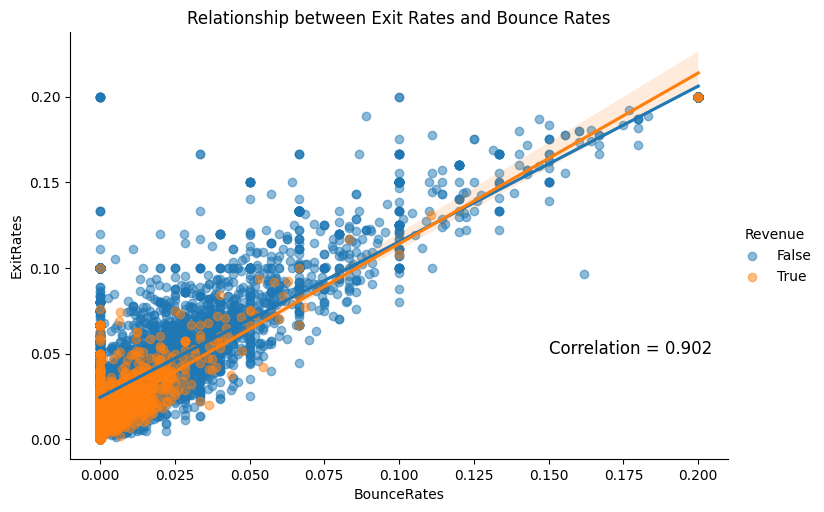

In [55]:
# Visualize the relationship between BounceRates and ExitRates, with Revenue as hue.
plt.figure(figsize=(8, 5))
sns.lmplot(data=df, x='BounceRates', y='ExitRates', hue='Revenue',
           scatter_kws={'alpha':0.5}, aspect=1.5)
plt.title("Relationship between Exit Rates and Bounce Rates")
# Calculate and display the correlation coefficient between BounceRates and ExitRates
corr_val = df['BounceRates'].corr(df['ExitRates'])
plt.text(0.15, 0.05, f'Correlation = {corr_val:.3f}', fontsize=12)
plt.show()

## ExitRates vs. BounceRates

**Key Observations**
- ExitRates and BounceRates exhibit a **very strong positive correlation (≈ 0.90)**.
- Sessions with higher bounce rates generally also have higher exit rates.
- Buyers and non-buyers largely follow the same linear relationship.
- The strong correlation suggests potential multicollinearity between these features.

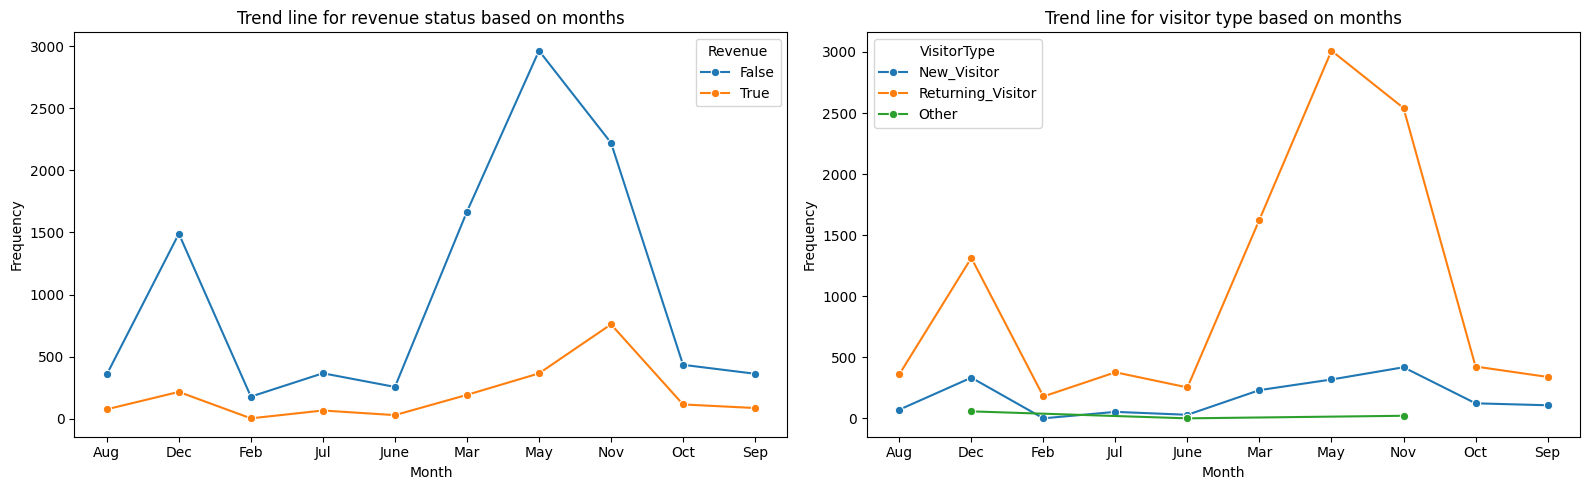

In [56]:
# Visualize monthly trends for revenue status and visitor type using subplots.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Group data by Month and Revenue to get purchase frequency trend
revenue_trend = df.groupby(['Month', 'Revenue']).size().reset_index(name='Frequency')
sns.lineplot(data=revenue_trend, x='Month', y='Frequency', hue='Revenue', marker="o", ax=axes[0])
axes[0].set_title("Trend line for revenue status based on months")

# Group data by Month and VisitorType to get visitor frequency trend
visitor_trend = df.groupby(['Month', 'VisitorType']).size().reset_index(name='Frequency')
sns.lineplot(data=visitor_trend, x='Month', y='Frequency', hue='VisitorType', marker="o", ax=axes[1])
axes[1].set_title("Trend line for visitor type based on months")

plt.tight_layout()
plt.show()

## Monthly Revenue & Visitor Trends

**Key Observations**
- Website traffic and purchases peak during **November**.
- Returning visitors consistently dominate monthly traffic across all months.
- Purchase volume generally follows the overall traffic trend.
- Seasonal effects appear to influence both visitor activity and conversions.

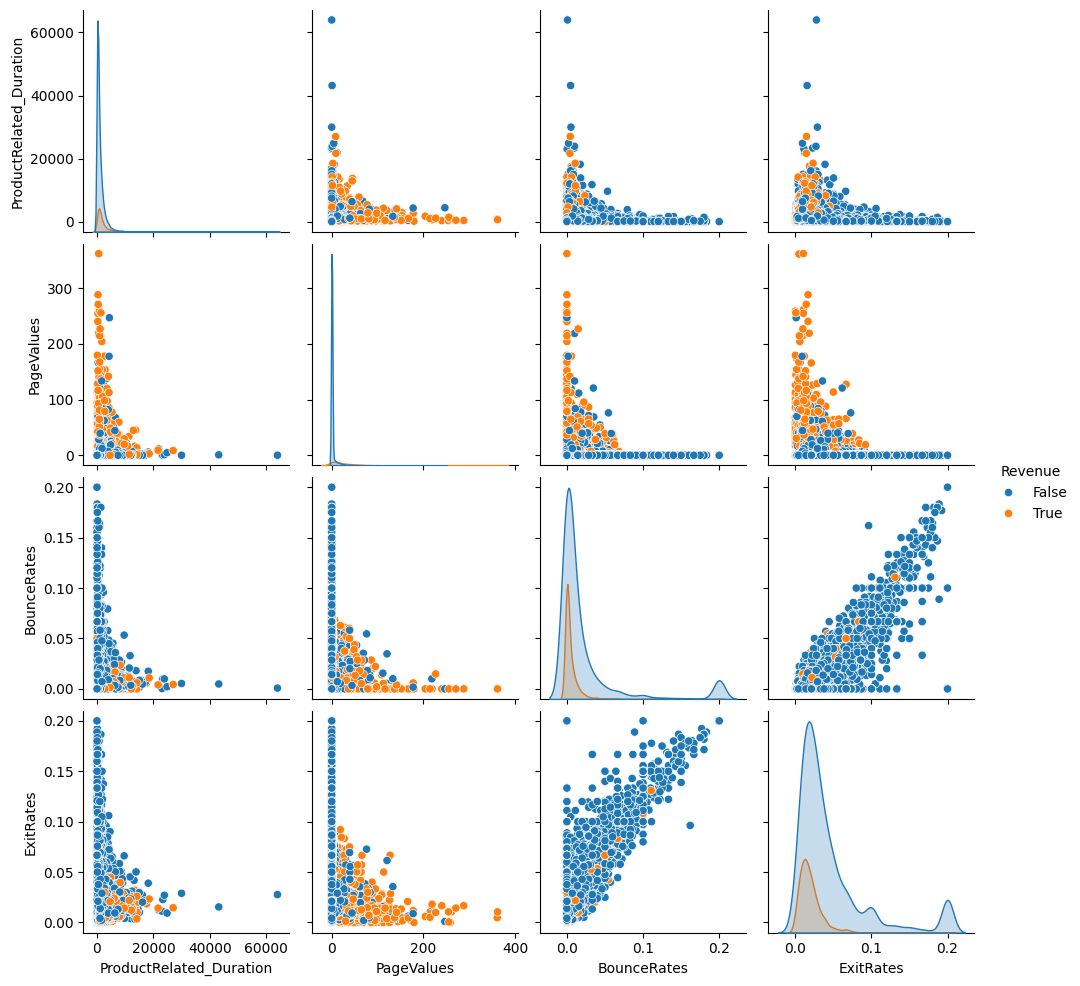

In [57]:
# Select relevant columns for pairplot analysis, including Revenue for hue.
selected = [
    'ProductRelated_Duration',
    'PageValues',
    'BounceRates',
    'ExitRates',
    'Revenue'
]
# Create a pairplot to visualize relationships and distributions of selected features, separated by Revenue.
sns.pairplot(
    df[selected],
    hue="Revenue"
)

## Pairplot Analysis

**Key Observations**
- BounceRates and ExitRates display a strong positive linear relationship.
- Higher PageValues are predominantly associated with purchasing sessions.
- Buyers generally spend more time on product-related pages.
- Most numerical features remain right-skewed with several extreme observations.

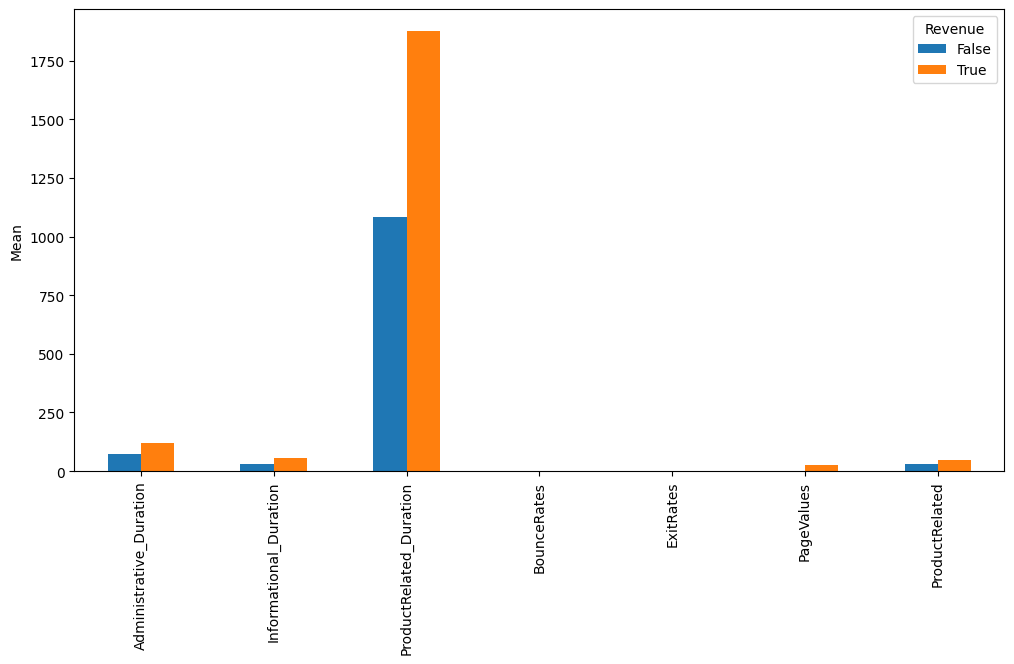

In [58]:
# Group the DataFrame by 'Revenue' and calculate the mean for each continuous column.
grouped = df.groupby("Revenue")[continuous_cols].mean().T

# Plot the grouped means as a bar chart to compare feature averages between buyers and non-buyers.
grouped.plot(kind="bar", figsize=(12,6))

plt.ylabel("Mean")

plt.show()

## Mean Feature Comparison by Revenue

**Key Observations**
- Buyers have higher average values across most engagement-related features.
- ProductRelated_Duration shows the largest difference between buyers and non-buyers.
- Buyers also exhibit higher ProductRelated counts, PageValues, and browsing durations.
- BounceRates and ExitRates are comparatively lower for buyers, indicating better engagement.

## Overall Summary of Multivariate Analysis

The multivariate analysis provides a comprehensive view of how multiple features interact to influence purchasing behavior. The results indicate that **customer engagement**, **visitor characteristics**, and **seasonal trends** collectively contribute to purchase decisions, while certain features exhibit strong interrelationships that should be considered during model development.

### Key Findings

- **Feature Relationships**
  - BounceRates and ExitRates exhibit a **very strong positive correlation (≈ 0.90)**, indicating that these variables capture similar user behavior and may introduce multicollinearity in predictive models.
  - Most buyers cluster around **low BounceRates and ExitRates**, reflecting stronger website engagement.

- **Customer Engagement**
  - Buyers consistently spend more time on product-related pages, visit more products, and generate significantly higher PageValues.
  - Product engagement features show the strongest separation between buyers and non-buyers.

- **Visitor Behavior**
  - Returning visitors dominate both overall website traffic and completed purchases.
  - New visitors contribute fewer conversions, highlighting the importance of customer retention.

- **Seasonal Trends**
  - Conversion activity varies across months, with **November** emerging as the strongest month for purchases.
  - Higher website traffic does not always correspond to higher conversion rates, suggesting seasonal differences in customer purchase intent.

- **Feature Importance**
  - ProductRelated, ProductRelated_Duration, PageValues, BounceRates, ExitRates, VisitorType, and Month consistently demonstrate meaningful relationships with the target variable (Revenue).
  - These features are likely to provide significant predictive power in machine learning models.

### Business Insights

The analysis suggests that **user engagement is the primary driver of online purchases**. Customers who spend more time exploring products, view more product pages, and generate higher PageValues are substantially more likely to complete a purchase. Additionally, returning visitors contribute the majority of conversions, emphasizing the value of customer retention initiatives. Seasonal patterns, particularly the surge in purchases during November, indicate opportunities for targeted marketing campaigns and inventory planning. Finally, the strong correlation between BounceRates and ExitRates suggests that feature selection or dimensionality reduction techniques may be beneficial during model development to reduce redundancy.

Overall, the multivariate analysis reinforces that **engagement-related metrics, visitor characteristics, and seasonal behavior are the most influential factors associated with purchase conversion**, providing valuable guidance for both business strategy and predictive modeling.

# Final EDA Summary: Top 10 Key Findings

The Exploratory Data Analysis (EDA) revealed several important patterns related to user behavior, website engagement, and purchase conversions. The following are the ten most significant insights obtained from the analysis.

### 1. Customer engagement is the strongest indicator of purchase behavior.
Users who viewed more product pages and spent longer browsing product-related content were significantly more likely to complete a purchase.

### 2. PageValues is one of the most informative features.
Buyers consistently exhibited much higher PageValues than non-buyers, making this feature a strong predictor of purchase intent.

### 3. Returning visitors drive the majority of conversions.
Most purchases were made by returning visitors, highlighting the importance of customer retention and repeat engagement.

### 4. Website traffic exhibits clear seasonal patterns.
Traffic and purchases varied across months, with **November** recording the highest number of conversions, indicating strong seasonal purchasing behavior.

### 5. Higher website traffic does not always result in higher sales.
Although **May** experienced the highest number of sessions, **November** achieved the highest purchase volume, suggesting that user purchase intent varies throughout the year.

### 6. Most numerical features are highly right-skewed with numerous outliers.
Duration, page count, and page value features contain long right tails, indicating that a small proportion of users exhibit exceptionally high engagement.

### 7. BounceRates and ExitRates are highly correlated.
A strong positive correlation (**0.90**) exists between BounceRates and ExitRates, suggesting that both variables capture similar aspects of user behavior and may introduce multicollinearity.

### 8. Greater user engagement is associated with lower bounce and exit rates.
Users who browsed more pages and spent longer on the website generally exhibited lower BounceRates and ExitRates, increasing the likelihood of conversion.

### 9. Technology and traffic distributions are highly imbalanced.
A small number of browsers, operating systems, traffic sources, and regions account for the majority of website sessions, indicating concentrated user behavior across specific categories.

### 10. Several features show strong predictive potential.
Based on the EDA, the features **ProductRelated**, **ProductRelated_Duration**, **PageValues**, **BounceRates**, **ExitRates**, **VisitorType**, and **Month** demonstrate the strongest relationships with the target variable (**Revenue**) and are expected to play a key role in predictive modeling.

---

## Conclusion

Overall, the analysis indicates that **customer engagement is the primary driver of online purchases**. Users who actively explore products, spend more time browsing, and revisit the website are substantially more likely to convert. Additionally, seasonal purchasing patterns and strong relationships among engagement metrics provide valuable insights for feature engineering, model development, and business decision-making.

##4. Data Preprocessing

#4.1 Feature Engineering

Feature Creation
* "Light" feature creation step.
* While Neural Networks are great at finding hidden patterns, feeding them explicitly combined features (like totals or averages) gives them a massive head start and often leads to faster convergence and better accuracy.

In [59]:
# 1. Total Page Views
df['Total_PageViews'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

# 2. Total Duration
df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']

# 3. Average Time Per Page
# (Adding 1 to the denominator prevents ZeroDivisionError for users who viewed 0 pages)
df['Avg_Time_Per_Page'] = df['Total_Duration'] / (df['Total_PageViews'] + 1)

#  Check the new columns to make sure they look right!
print(df[['Total_PageViews', 'Total_Duration', 'Avg_Time_Per_Page']].head())


   Total_PageViews  Total_Duration  Avg_Time_Per_Page
0                1        0.000000           0.000000
1                2       64.000000          21.333333
2                1        0.000000           0.000000
3                2        2.666667           0.888889
4               10      627.500000          57.045455


### Justification

* Feature engineering was performed to derive additional variables that better represent user browsing behavior and engagement.
* Instead of relying solely on the original features, new attributes such as `Total_PageViews`, `Total_Duration`, and `Avg_Time_Per_Page` were created by combining existing information. These engineered features provide a more comprehensive representation of user interaction with the website and may improve the model's ability to distinguish between purchasing and non-purchasing sessions.

#4.2 Feature Encoding

In [60]:
# ===============================
# Feature Encoding
# ===============================

# Categorical features to encode
categorical_features = [
    'Month',
    'VisitorType',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

# Convert boolean columns to integers
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

# Display dataset information
print(f"Original Dataset Shape : {df.shape}")
print(f"Encoded Dataset Shape  : {df_encoded.shape}")

df_encoded.head()

Original Dataset Shape : (12205, 21)
Encoded Dataset Shape  : (12205, 78)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
# Verify the encoded dataset

print(f"Original Shape : {df.shape}")
print(f"Encoded Shape  : {df_encoded.shape}")

print("\nRemaining Data Types:")
print(df_encoded.dtypes.value_counts())

Original Shape : (12205, 21)
Encoded Shape  : (12205, 78)

Remaining Data Types:
int64      69
float64     9
Name: count, dtype: int64


### Justification

* Artificial Neural Networks require numerical input features and cannot directly process categorical variables. Therefore, all categorical attributes were transformed into numerical representations using **One-Hot Encoding**.

* Features such as **Month**, **VisitorType**, **OperatingSystems**, **Browser**, **Region**, and **TrafficType** represent nominal categories with no inherent ordering. One-Hot Encoding preserves each category independently without introducing artificial ordinal relationships.

* Boolean variables were converted to integer values (0 and 1) to ensure compatibility with the machine learning models while preserving their binary meaning.

#4.3 Feature and Target Separation

The encoded dataset was divided into input features (X) and the target variable (y). The target variable is `Revenue`, which indicates whether a customer completed a purchase during the browsing session.

In [62]:
# ===============================
# Feature and Target Separation
# ===============================

X = df_encoded.drop("Revenue", axis=1)
y = df_encoded["Revenue"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Feature Matrix Shape : (12205, 77)
Target Vector Shape  : (12205,)


#4.4 Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. Stratified sampling was used to preserve the original class distribution of the target variable in both subsets.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (9764, 77)
Testing Set  : (2441, 77)


#4.5 Feature Scaling

Numerical features were standardized using StandardScaler.
The scaler was fitted only on the training data to prevent data leakage and then applied to both the training and testing sets.

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

Training Shape : (9764, 77)
Testing Shape  : (2441, 77)


### Justification

* The numerical features in the dataset have substantially different ranges. For example, `BounceRates` ranges between 0 and 0.2, whereas `ProductRelated_Duration` can exceed several thousand seconds. Such differences may cause features with larger magnitudes to dominate the optimization process.

* To address this issue, **StandardScaler** was applied to standardize the numerical features to a common scale with zero mean and unit variance. The scaler was fitted only on the training data and subsequently applied to the testing data to prevent data leakage.

#4.6 Handling Class Imbalance

The target variable exhibited class imbalance, with significantly fewer purchase sessions than non-purchase sessions.
Synthetic Minority Over-sampling Technique (SMOTE) was applied only to the training dataset to generate synthetic samples of the minority class while keeping the testing dataset unchanged for unbiased evaluation.

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Training Shape After SMOTE :", X_train_smote.shape)
print(y_train_smote.value_counts())

Training Shape After SMOTE : (16476, 77)
Revenue
1    8238
0    8238
Name: count, dtype: int64


### Justification

* The target variable is imbalanced, with significantly more non-purchasing sessions than purchasing sessions. Training a model on such imbalanced data may bias it toward predicting the majority class, resulting in poor identification of actual purchase sessions.

* To mitigate this issue, the **Synthetic Minority Over-sampling Technique (SMOTE)** was applied exclusively to the training dataset. SMOTE generates synthetic examples of the minority class, enabling the model to learn more balanced decision boundaries while leaving the testing dataset unchanged for unbiased performance evaluation.

### Data Preprocessing Summary

The dataset is now fully prepared for machine learning. Categorical variables have been encoded, engineered features have been incorporated, numerical features have been standardized, and class imbalance has been addressed using SMOTE. The resulting training and testing datasets are suitable for developing and evaluating baseline machine learning models as well as the Artificial Neural Network.

#5. Baseline Machine Learning Models

Before developing the Artificial Neural Network (ANN), several traditional machine learning classification algorithms were trained to establish baseline performance. These baseline models provide a reference point for evaluating whether the ANN offers meaningful improvements in predicting online purchasing behavior.

The following baseline models were considered:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Each model was trained using the preprocessed training dataset and evaluated on the unseen test dataset using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix.

#5.1 Logistic Regression


Logistic Regression was selected as the first baseline model because it is one of the most widely used algorithms for binary classification problems. It provides a simple and interpretable benchmark against which more complex models can be compared.

Although Logistic Regression assumes a linear relationship between the input features and the log-odds of the target variable, it often performs competitively on structured datasets and serves as an important reference model before introducing tree-based methods and Artificial Neural Networks.

In [66]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ===============================
# Logistic Regression Model
# ===============================

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [67]:
# Predictions

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

In [68]:
# Logistic Regression Performance

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8599
Precision: 0.5362
Recall   : 0.7749
F1 Score : 0.6338
ROC AUC  : 0.9084


In [69]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      2059
           1       0.54      0.77      0.63       382

    accuracy                           0.86      2441
   macro avg       0.75      0.83      0.77      2441
weighted avg       0.89      0.86      0.87      2441



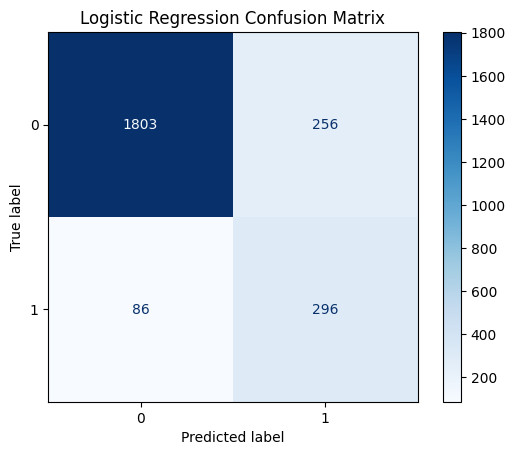

In [70]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Logistic Regression Results

Logistic Regression was used as the baseline model to predict whether a visitor would generate revenue.

### Performance Metrics

| Metric | Score |
|---------|------:|
| Accuracy | **0.8599** |
| Precision | **0.5362** |
| Recall | **0.7749** |
| F1-Score | **0.6338** |
| ROC-AUC | **0.9084** |

### Classification Report

| Class | Precision | Recall | F1-Score |
|------|----------:|-------:|---------:|
| No Purchase (0) | **0.95** | **0.88** | **0.91** |
| Purchase (1) | **0.54** | **0.77** | **0.63** |

### Confusion Matrix

- **TN:** 1803
- **FP:** 256
- **FN:** 86
- **TP:** 296

### Key Findings

- Achieved **85.99% accuracy** with excellent class discrimination (**ROC-AUC: 0.9084**).
- High **recall (77.49%)** indicates the model identifies most purchasing sessions.
- **Precision (53.62%)** is moderate due to the class imbalance, resulting in more false positives.
- Overall, Logistic Regression provides a strong baseline for comparing more advanced models.

In [71]:
baseline_results = []
# Saving Results
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

baseline_results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1,
    "ROC AUC": lr_roc_auc
})

#5.2 Decision Tree Classifier


Decision Tree is a non-linear supervised learning algorithm capable of capturing complex relationships between input features and the target variable. Unlike Logistic Regression, it does not assume a linear decision boundary and can naturally model feature interactions.

Decision Trees are widely used because they are easy to interpret and can identify the most informative decision rules. This makes them an excellent baseline model for comparing against more advanced techniques such as Random Forests and Artificial Neural Networks.

In [72]:
from sklearn.tree import DecisionTreeClassifier

# ===============================
# Decision Tree Classifier
# ===============================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)


# Predictions

y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

In [73]:
# Decision Tree Performance

accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt)
recall = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
roc_auc = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8562
Precision: 0.5345
Recall   : 0.6283
F1 Score : 0.5776
ROC AUC  : 0.7634


In [74]:
# Classification Reprt
print(classification_report(
    y_test,
    y_pred_dt
))

              precision    recall  f1-score   support

           0       0.93      0.90      0.91      2059
           1       0.53      0.63      0.58       382

    accuracy                           0.86      2441
   macro avg       0.73      0.76      0.75      2441
weighted avg       0.87      0.86      0.86      2441



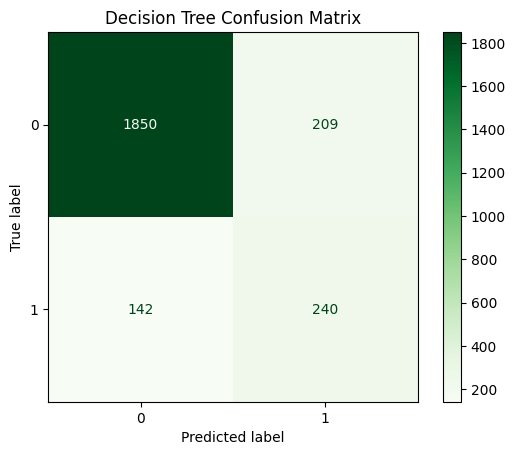

In [75]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [76]:
# SavinG Results
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

baseline_results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "ROC AUC": dt_roc_auc
})

## Decision Tree Classifier Results

A Decision Tree Classifier was trained on the SMOTE-balanced dataset to predict whether a visitor would generate revenue.

### Performance Metrics

| Metric | Score |
|---------|------:|
| Accuracy | **0.8562** |
| Precision | **0.5345** |
| Recall | **0.6283** |
| F1-Score | **0.5776** |
| ROC-AUC | **0.7634** |

### Classification Report

| Class | Precision | Recall | F1-Score |
|------|----------:|-------:|---------:|
| No Purchase (0) | **0.93** | **0.90** | **0.91** |
| Purchase (1) | **0.53** | **0.63** | **0.58** |

### Confusion Matrix

- **TN:** 1850
- **FP:** 209
- **FN:** 142
- **TP:** 240

### Key Findings

- Achieved **85.62% accuracy** with moderate class discrimination (**ROC-AUC: 0.7634**).
- **Recall (62.83%)** is lower than Logistic Regression, resulting in more missed buyers.
- **Precision (53.45%)** is similar to Logistic Regression despite fewer false positives.
- Overall, the Decision Tree performs well on non-purchasers but is less effective at identifying purchasing sessions.

#5.4 Random Forest Classifier


Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting. Unlike a single Decision Tree, Random Forest aggregates the predictions of many trees, resulting in better generalization and more stable performance.

Random Forest is widely regarded as one of the strongest traditional machine learning algorithms for structured tabular datasets. Therefore, it serves as an excellent benchmark for evaluating whether the Artificial Neural Network provides a meaningful improvement in predicting online purchasing behavior.

In [77]:
from sklearn.ensemble import RandomForestClassifier


# ===============================
# Random Forest Classifier
# ===============================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

In [78]:
# Random Forest Performance

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Accuracy : 0.8951
Precision: 0.6507
Recall   : 0.7120
F1 Score : 0.6800
ROC AUC  : 0.9187


In [79]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2059
           1       0.65      0.71      0.68       382

    accuracy                           0.90      2441
   macro avg       0.80      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



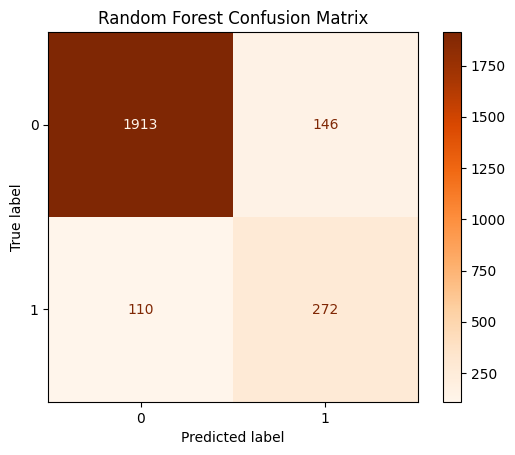

In [80]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [81]:
# Saving Results
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

baseline_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC AUC": rf_roc_auc
})

## Random Forest Classifier Results

A Random Forest Classifier was trained on the SMOTE-balanced dataset to predict whether a visitor would generate revenue.

### Performance Metrics

| Metric | Score |
|---------|------:|
| Accuracy | **0.8951** |
| Precision | **0.6507** |
| Recall | **0.7120** |
| F1-Score | **0.6800** |
| ROC-AUC | **0.9187** |

### Classification Report

| Class | Precision | Recall | F1-Score |
|------|----------:|-------:|---------:|
| No Purchase (0) | **0.95** | **0.93** | **0.94** |
| Purchase (1) | **0.65** | **0.71** | **0.68** |

### Confusion Matrix

- **TN:** 1913
- **FP:** 146
- **FN:** 110
- **TP:** 272

### Key Findings

- Achieved the highest **accuracy (89.51%)** with excellent class discrimination (**ROC-AUC: 0.9187**).
- **Precision (65.07%)** is significantly higher than previous models, reducing false positives.
- **Recall (71.20%)** remains strong, capturing most purchasing sessions.
- Overall, Random Forest delivers the best balance of accuracy, precision, recall, and F1-score among the evaluated models.

#5.6 Baseline Model Comparison

* The performance of the baseline machine learning models was compared using multiple evaluation metrics.
* This comparison establishes a reference point for determining whether the Artificial Neural Network provides meaningful improvements in predicting customer purchasing behavior.

In [82]:
# Comparison
results_df = pd.DataFrame(baseline_results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.8951,0.6507,0.7120,0.6800,0.9187
0,Logistic Regression,0.8599,0.5362,0.7749,0.6338,0.9084
1,Decision Tree,0.8562,0.5345,0.6283,0.5776,0.7634


### Interpretation

The three baseline models were compared using **Accuracy, Precision, Recall, F1-Score, and ROC-AUC** to evaluate their ability to predict purchasing sessions.

- **Random Forest** achieved the **best overall performance**, recording the highest **Accuracy (89.51%)**, **Precision (65.07%)**, **F1-Score (68.00%)**, and **ROC-AUC (0.9187)** while maintaining strong **Recall (71.20%)**. This indicates that the ensemble model captured user purchasing patterns more effectively than the other approaches.

- **Logistic Regression** delivered a strong baseline with **85.99% Accuracy** and an excellent **ROC-AUC of 0.9084**. Although it identified buyers effectively, its lower Precision and F1-Score resulted in more false positives than Random Forest.

- **Decision Tree** showed the weakest performance, with the lowest **F1-Score (57.76%)** and **ROC-AUC (0.7634)**. While it models non-linear relationships, a single tree is more prone to overfitting and generalizes less effectively than ensemble methods.

**Overall, Random Forest emerged as the best-performing traditional machine learning model and will serve as the primary benchmark for evaluating the Artificial Neural Network (ANN) in the next section.**

# 6. Artificial Neural Network (Baseline)

* Artificial Neural Networks (ANNs) are computational models inspired by the structure and functioning of biological neural networks. Unlike traditional machine learning algorithms, ANNs can learn complex non-linear relationships between input features and the target variable through multiple interconnected layers of neurons.

* In this project, a baseline ANN model is developed to predict whether a visitor will complete an online purchase based on their browsing behavior. The baseline architecture serves as a reference model before applying hyperparameter tuning and architectural improvements.

In [83]:
# Required Imports
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## 6.1 Baseline ANN Architecture


* A simple feedforward neural network was selected as the baseline architecture. The network consists of two hidden layers using the ReLU activation function, followed by a single output neuron with a Sigmoid activation function for binary classification.

* The architecture is intentionally kept simple to establish a baseline performance before exploring more sophisticated network configurations through hyperparameter tuning.

In [84]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ============================================
# Baseline Artificial Neural Network
# ============================================

ann_model = Sequential([

    Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,041 (11.88 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

The model was compiled using the Adam optimizer and Binary Cross-Entropy loss function. Adam provides efficient gradient-based optimization, while Binary Cross-Entropy is the standard loss function for binary classification problems. Accuracy was selected as the primary optimization metric during training.

In [85]:
from tensorflow.keras.optimizers import Adam

# Model Compilation
ann_model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
# Train Model
history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7854 - loss: 0.4615 - val_accuracy: 0.7121 - val_loss: 0.5171
Epoch 2/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8520 - loss: 0.3479 - val_accuracy: 0.7961 - val_loss: 0.4153
Epoch 3/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8723 - loss: 0.3037 - val_accuracy: 0.8486 - val_loss: 0.3449
Epoch 4/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.2788 - val_accuracy: 0.8750 - val_loss: 0.3222
Epoch 5/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8882 - loss: 0.2617 - val_accuracy: 0.8683 - val_loss: 0.3110
Epoch 6/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8929 - loss: 0.2488 - val_accuracy: 0.8941 - val_loss: 0.2710
Epoch 7/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8984 - loss: 0.2415 - val_accuracy: 0.9147 - val_loss: 0.2372
Epoch 8/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.2330 - val_accuracy: 0.

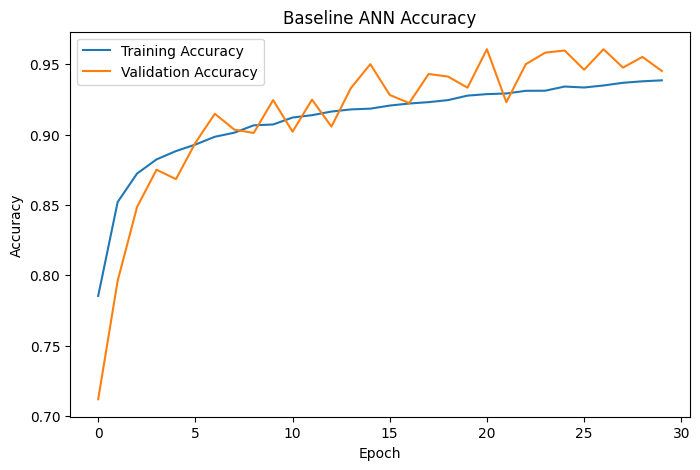

In [87]:
# Learning Curves
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ANN Accuracy")

plt.legend()

plt.show()

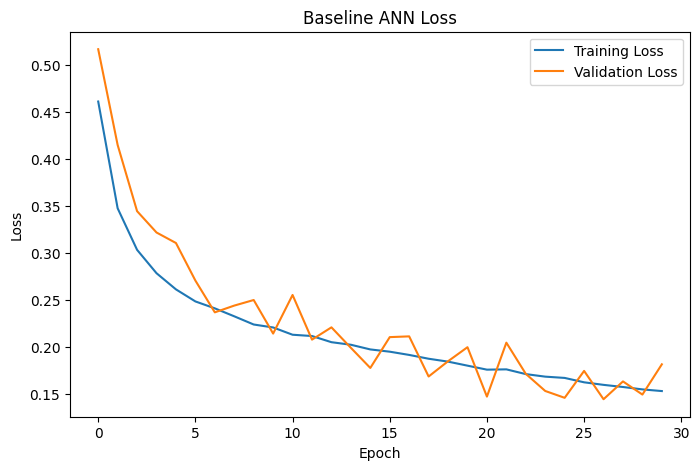

In [88]:
# Baeline ANN loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline ANN Loss")

plt.legend()

plt.show()

In [89]:
# Prediction
y_prob_ann = ann_model.predict(X_test_scaled)

y_pred_ann = (y_prob_ann > 0.5).astype(int)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [90]:
# Evaluation
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_prob_ann)

print(f"Accuracy : {ann_accuracy:.4f}")
print(f"Precision: {ann_precision:.4f}")
print(f"Recall   : {ann_recall:.4f}")
print(f"F1 Score : {ann_f1:.4f}")
print(f"ROC AUC  : {ann_auc:.4f}")

Accuracy : 0.8730
Precision: 0.5776
Recall   : 0.7016
F1 Score : 0.6336
ROC AUC  : 0.8918


In [91]:
# Classification Report
print(classification_report(
    y_test,
    y_pred_ann
))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2059
           1       0.58      0.70      0.63       382

    accuracy                           0.87      2441
   macro avg       0.76      0.80      0.78      2441
weighted avg       0.89      0.87      0.88      2441



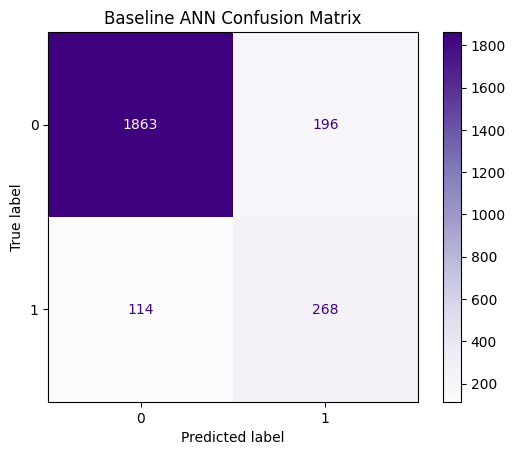

In [92]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ann,
    cmap="Purples"
)

plt.title("Baseline ANN Confusion Matrix")
plt.show()

In [93]:
# Saving Results
baseline_results.append({
    "Model": "Baseline ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1 Score": ann_f1,
    "ROC AUC": ann_auc
})

#7. Hyperparameter Tuning

* The baseline Artificial Neural Network produced satisfactory performance; however, there is still scope for improvement. Hyperparameter tuning was performed to investigate whether modifications to the network architecture and training strategy could improve predictive performance.

* Instead of randomly changing multiple parameters simultaneously, controlled experiments were conducted by modifying one aspect of the network at a time. This approach allows the impact of each hyperparameter to be evaluated independently.

## Experiment 1: Increasing Network Capacity

---

* The baseline ANN consisted of two hidden layers with 32 and 16 neurons. Although this architecture achieved good performance, it may not have sufficient capacity to learn more complex relationships within the data.

* To investigate this, the number of neurons was increased to 64 and 32 respectively while keeping all other hyperparameters unchanged. This experiment evaluates whether a larger network can improve classification performance.

In [94]:
# ==========================================
# Experiment 1 - Larger Neural Network
# ==========================================

exp1_model = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_smote.shape[1],)),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

exp1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 7,105 (27.75 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
# Compile
exp1_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [96]:
# Train
history_exp1 = exp1_model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7983 - loss: 0.4341 - val_accuracy: 0.8292 - val_loss: 0.3756
Epoch 2/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8630 - loss: 0.3238 - val_accuracy: 0.8650 - val_loss: 0.3257
Epoch 3/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8816 - loss: 0.2827 - val_accuracy: 0.8759 - val_loss: 0.3034
Epoch 4/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8907 - loss: 0.2583 - val_accuracy: 0.8965 - val_loss: 0.2776
Epoch 5/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8998 - loss: 0.2387 - val_accuracy: 0.9062 - val_loss: 0.2446
Epoch 6/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9072 - loss: 0.2241 - val_accuracy: 0.9248 - val_loss: 0.2279
Epoch 7/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9108 - loss: 0.2104 - val_accuracy: 0.9478 - val_loss: 0.1814
Epoch 8/30
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9175 - loss: 0.2024 - val_accuracy: 0.

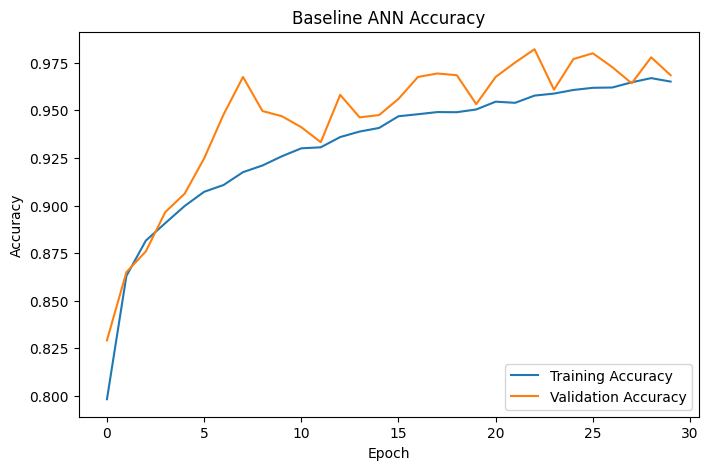

In [105]:
# Learning Curves
plt.figure(figsize=(8,5))

plt.plot(history_exp1.history['accuracy'], label='Training Accuracy')
plt.plot(history_exp1.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ANN Accuracy")

plt.legend()

plt.show()

In [97]:
# Evaluate
y_prob_exp1 = exp1_model.predict(X_test_scaled)
y_pred_exp1 = (y_prob_exp1 > 0.5).astype(int)

exp1_accuracy = accuracy_score(y_test, y_pred_exp1)
exp1_precision = precision_score(y_test, y_pred_exp1)
exp1_recall = recall_score(y_test, y_pred_exp1)
exp1_f1 = f1_score(y_test, y_pred_exp1)
exp1_auc = roc_auc_score(y_test, y_prob_exp1)

print(f"Accuracy : {exp1_accuracy:.4f}")
print(f"Precision: {exp1_precision:.4f}")
print(f"Recall   : {exp1_recall:.4f}")
print(f"F1 Score : {exp1_f1:.4f}")
print(f"ROC AUC  : {exp1_auc:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.8603
Precision: 0.5514
Recall   : 0.5759
F1 Score : 0.5634
ROC AUC  : 0.8682


In [98]:
# Saving Results
baseline_results.append({
    "Model": "Baseline ANN",
    "Accuracy": exp1_accuracy,
    "Precision": exp1_precision,
    "Recall": exp1_recall,
    "F1 Score": exp1_f1,
    "ROC AUC": exp1_auc
})

### Observation of Experiment 1: Increasing Network Capacity
* In the first hyperparameter tuning experiment, the number of neurons in the hidden layers was increased from **32–16** to **64–32** while keeping all other hyperparameters unchanged.
* Contrary to expectations, the larger network produced lower performance across all evaluation metrics. Accuracy decreased from **87.79%** to **86.03%**, F1-Score dropped from **0.6392** to **0.5634**, and ROC-AUC decreased from **0.8939** to **0.8682**.
* These results indicate that simply increasing the network capacity did not improve the model's ability to generalize on this dataset. Therefore, the original baseline architecture was retained, and subsequent tuning focused on improving the training strategy rather than increasing model complexity.

## Experiment 2: Early Stopping

---

* The baseline ANN was trained for a fixed number of epochs, which may result in unnecessary training once the model has converged. To improve training efficiency and prevent potential overfitting, the **EarlyStopping** callback was introduced.

* EarlyStopping monitors the validation loss during training and automatically terminates the training process when no further improvement is observed. The best-performing model weights are restored, ensuring that the final model corresponds to the epoch with the lowest validation loss rather than the final training epoch.

In [99]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping Callback

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [100]:
# Build Model

exp2_model = Sequential([

    Dense(32, activation='relu', input_shape=(X_train_smote.shape[1],)),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [101]:
# Compile

exp2_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [102]:
# Epochs 100 - As we are using Early Stopping

history_exp2 = exp2_model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7273 - loss: 0.5108 - val_accuracy: 0.7394 - val_loss: 0.5206
Epoch 2/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8423 - loss: 0.3532 - val_accuracy: 0.7491 - val_loss: 0.4733
Epoch 3/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8678 - loss: 0.3103 - val_accuracy: 0.8434 - val_loss: 0.3588
Epoch 4/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8812 - loss: 0.2845 - val_accuracy: 0.8522 - val_loss: 0.3478
Epoch 5/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8880 - loss: 0.2667 - val_accuracy: 0.8632 - val_loss: 0.3214
Epoch 6/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8929 - loss: 0.2544 - val_accuracy: 0.8774 - val_loss: 0.2950
Epoch 7/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8976 - loss: 0.2427 - val_accuracy: 0.8968 - val_loss: 0.2731
Epoch 8/100
412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9001 - loss: 0.2359 - val_accu

In [103]:
# Evaluate

y_prob_exp2 = exp2_model.predict(X_test_scaled)
y_pred_exp2 = (y_prob_exp2 > 0.5).astype(int)

exp2_accuracy = accuracy_score(y_test, y_pred_exp2)
exp2_precision = precision_score(y_test, y_pred_exp2)
exp2_recall = recall_score(y_test, y_pred_exp2)
exp2_f1 = f1_score(y_test, y_pred_exp2)
exp2_auc = roc_auc_score(y_test, y_prob_exp2)

print(f"Accuracy : {exp2_accuracy:.4f}")
print(f"Precision: {exp2_precision:.4f}")
print(f"Recall   : {exp2_recall:.4f}")
print(f"F1 Score : {exp2_f1:.4f}")
print(f"ROC AUC  : {exp2_auc:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.8693
Precision: 0.5602
Recall   : 0.7670
F1 Score : 0.6475
ROC AUC  : 0.9055


In [106]:
# Saving Results
baseline_results.append({
    "Model": "Baseline ANN",
    "Accuracy": exp2_accuracy,
    "Precision": exp2_precision,
    "Recall": exp2_recall,
    "F1 Score": exp2_f1,
    "ROC AUC": exp2_auc
})

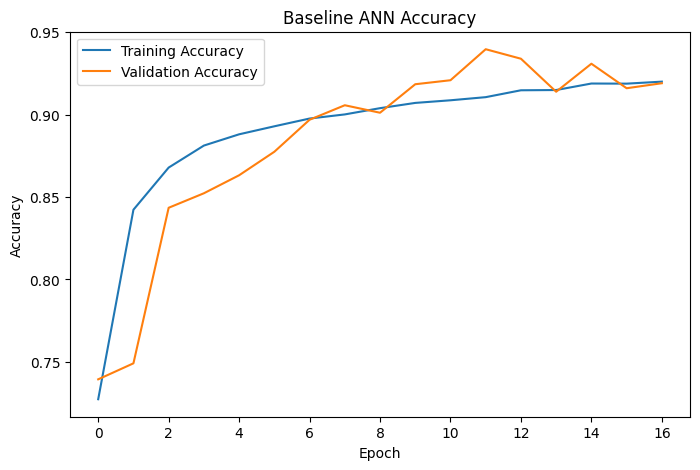

In [104]:
# Learning Curves
plt.figure(figsize=(8,5))

plt.plot(history_exp2.history['accuracy'], label='Training Accuracy')
plt.plot(history_exp2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline ANN Accuracy")

plt.legend()

plt.show()

### Observation of Experiment 2: Early Stopping

* EarlyStopping was introduced to automatically terminate training when the validation loss stopped improving.
* Compared with the baseline ANN, the model achieved a higher **Recall (69.11% → 76.70%)**, **F1-Score (0.6392 → 0.6475)**, and **ROC-AUC (0.8939 → 0.9055)**, indicating better identification of purchasing sessions. Although Accuracy decreased slightly from **87.79%** to **86.93%**, the improvement in Recall and F1-Score suggests that EarlyStopping enhanced the model's generalization performance and produced a more balanced classifier.

# 8. Final Model Comparison

* The performance of all developed machine learning and deep learning models was compared using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

* The objective of this comparison is to identify the model that provides the best balance between correctly identifying purchasing sessions and minimizing misclassification errors. The comparison also evaluates whether the Artificial Neural Network offers meaningful improvements over traditional machine learning algorithms.

# Results Table

In [108]:
final_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_accuracy,
        "Precision": lr_precision,
        "Recall": lr_recall,
        "F1 Score": lr_f1,
        "ROC AUC": lr_roc_auc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1 Score": dt_f1,
        "ROC AUC": dt_roc_auc
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC AUC": rf_roc_auc
    },
    {
        "Model": "Baseline ANN",
        "Accuracy": ann_accuracy,
        "Precision": ann_precision,
        "Recall": ann_recall,
        "F1 Score": ann_f1,
        "ROC AUC": ann_auc
    },
    {
        "Model": "Tuned ANN - Large Architecture",
        "Accuracy": exp1_accuracy,
        "Precision": exp1_precision,
        "Recall": exp1_recall,
        "F1 Score": exp1_f1,
        "ROC AUC": exp1_auc
    },
    {
        "Model": "Tuned ANN- Early Stopping",
        "Accuracy": exp2_accuracy,
        "Precision": exp2_precision,
        "Recall": exp2_recall,
        "F1 Score": exp2_f1,
        "ROC AUC": exp2_auc
    }
]

comparison_df = pd.DataFrame(final_results)

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.8951,0.6507,0.7120,0.6800,0.9187
5,Tuned ANN- Early Stopping,0.8693,0.5602,0.7670,0.6475,0.9055
0,Logistic Regression,0.8599,0.5362,0.7749,0.6338,0.9084
3,Baseline ANN,0.8730,0.5776,0.7016,0.6336,0.8918
1,Decision Tree,0.8562,0.5345,0.6283,0.5776,0.7634
4,Tuned ANN - Large Architecture,0.8603,0.5514,0.5759,0.5634,0.8682


# F1-Score Comparison

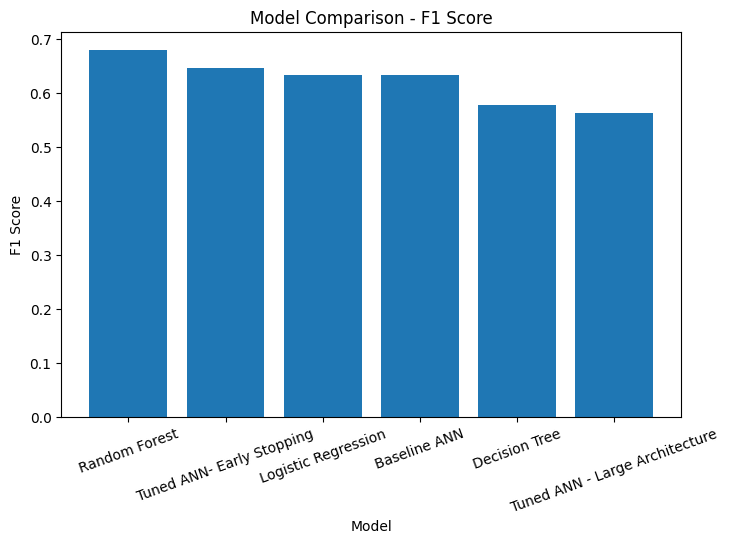

In [109]:
# Bar Chart for - F1 Score Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

# ROC-AUC Comparison

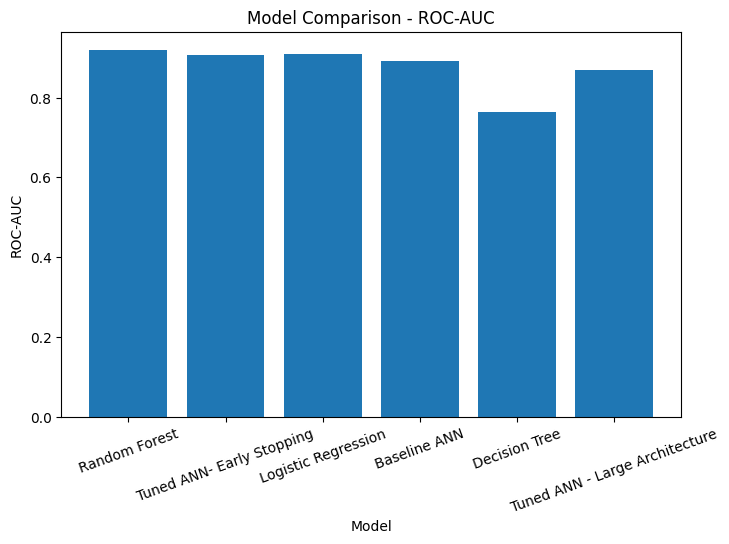

In [110]:
# Bar Chart for ROC-AUC Comparison
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC AUC"]
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.show()

## Performance Comparison Summary

- **Top Performer:** The **Random Forest** classifier delivers the best overall performance among all evaluated models. It achieves the highest **Accuracy (89.51%)**, **Precision (65.07%)**, **F1-Score (68.00%)**, and **ROC-AUC (0.9187)**, demonstrating excellent predictive capability and the strongest balance between correctly identifying purchasers while minimizing false predictions.

- **Deep Learning Performance:** The **Tuned Artificial Neural Network (Early Stopping)** successfully mitigates the overfitting observed in the Baseline ANN. It improves **Recall by 6.54%** and **F1-Score by 1.39%**, resulting in better generalization and establishing it as the strongest-performing deep learning model evaluated in this study.

- **Targeted Strengths:** Although **Random Forest** provides the best overall predictive performance, **Logistic Regression** achieves the highest **Recall (77.49%)**, making it particularly suitable for applications where minimizing false negatives (missing potential buyers) is more important than maximizing precision.

- **Underperformers:** The **Decision Tree** and the over-parameterized **Tuned ANN (Large Architecture)** exhibit comparatively weaker performance across most evaluation metrics. Their lower F1-Scores and reduced generalization capability indicate that they are less effective for predicting customer purchase behavior than the other evaluated models.
---
## Performance Comparison of Machine Learning and Deep Learning Models

| **Model** | **Accuracy** | **Precision** | **Recall** | **F1 Score** | **ROC-AUC** |
|:---------------------------------|-----------:|------------:|---------:|----------:|----------:|
| **Random Forest** | 🥇 **0.8951** | 🥇 **0.6507** | 0.7120 | 🥇 **0.6800** | 🥇 **0.9187** |
| Tuned ANN (Early Stopping) | 0.8693 | 0.5602 | 🥈 0.7670 | 🥈 0.6475 | 🥈 0.9055 |
| Logistic Regression | 🔻 0.8599 | 🔻 0.5362 | 🥇 **0.7749** | 0.6338 | 🥈 0.9084 |
| Baseline ANN | 🥈 0.8730 | 🥈 0.5776 | 0.7016 | 0.6336 | 0.8918 |
| Decision Tree | 🔻 0.8562 | 🔻 0.5345 | 0.6283 | 0.5776 | 🔻 0.7634 |
| Tuned ANN (Large Architecture) | 0.8603 | 0.5514 | 🔻 0.5759 | 🔻 0.5634 | 0.8682 |

**Legend:**
- 🥇 **Best-performing model** for the evaluation metric.
- 🥈 **Second-best performing model** for the evaluation metric.
- 🔻 **Lowest-performing model** for the evaluation metric.

#9. Generalization and Overfitting

* The learning curves of the baseline and tuned Artificial Neural Networks indicate that the models achieved **good generalization performance** on unseen data. Training and validation accuracy increased consistently throughout the training process, while both training and validation loss decreased without exhibiting significant divergence. The absence of a widening gap between the training and validation curves suggests that the models did not suffer from severe overfitting.

* During hyperparameter tuning, increasing the network capacity from **32–16 neurons** to **64–32 neurons** resulted in a decline in Accuracy, F1-Score, and ROC-AUC. This indicates that simply increasing model complexity did not improve generalization and may have introduced unnecessary complexity for this dataset.

* The introduction of **EarlyStopping** improved the model's generalization by automatically terminating training once the validation loss stopped improving and restoring the best-performing model weights. Although the tuned ANN experienced a slight reduction in overall Accuracy, it achieved higher Recall, F1-Score, and ROC-AUC, demonstrating a better balance between identifying purchasing sessions and minimizing misclassification.

Overall, the experimental results suggest that the chosen baseline architecture was appropriately sized for the dataset and that improvements in training strategy were more beneficial than increasing network complexity. The final tuned ANN demonstrated stable learning behavior and satisfactory generalization, while the Random Forest classifier remained the best-performing model for this structured tabular dataset.

# 10. Conclusion

* This project aimed to develop a machine learning and deep learning solution for predicting **online shoppers' purchasing intention** based on their browsing behavior. A systematic end-to-end machine learning pipeline was implemented, beginning with data inspection, preprocessing, exploratory data analysis, feature engineering, feature encoding, feature scaling, and class imbalance handling using SMOTE.

* Exploratory Data Analysis revealed several important characteristics of the dataset. Most numerical features exhibited right-skewed distributions, purchasing sessions represented the minority class, and user engagement variables such as **ProductRelated**, **ProductRelated_Duration**, and **PageValues** showed strong relationships with purchasing behavior. Feature engineering further enhanced the dataset by creating aggregated behavioral features while avoiding unnecessary redundancy.

* Multiple baseline machine learning models, including **Logistic Regression**, **Decision Tree**, and **Random Forest**, were developed to establish performance benchmarks. Among these models, **Random Forest** achieved the strongest overall performance, demonstrating the highest Accuracy, Precision, F1-Score, and ROC-AUC, making it the most effective model for this structured tabular dataset.

* The primary objective of this project was to develop and evaluate an **Artificial Neural Network (ANN)**. A baseline ANN with two hidden layers successfully learned the underlying patterns in the data and produced competitive predictive performance. Hyperparameter tuning was then performed through controlled experiments. Increasing the network size from **32–16** neurons to **64–32** neurons resulted in reduced performance, indicating that additional model complexity did not improve generalization. In contrast, introducing **EarlyStopping** improved Recall, F1-Score, and ROC-AUC by preventing unnecessary training and restoring the best-performing model weights.

* Overall, the project demonstrates the importance of systematic experimentation rather than assuming that more complex neural network architectures always produce better results. The results show that appropriate preprocessing, feature engineering, and training strategies significantly influence model performance. While the **Random Forest classifier** remained the best-performing model for this dataset, the tuned Artificial Neural Network demonstrated strong generalization capability and provided valuable insights into applying deep learning techniques for binary classification problems.

This project successfully fulfilled its objective of designing, implementing, evaluating, and comparing multiple predictive models for online purchasing intention. The developed workflow provides a reproducible machine learning pipeline that can serve as a foundation for future improvements, such as advanced feature engineering, automated hyperparameter optimization, ensemble learning, and more sophisticated deep learning architectures.